# **Binary Prediction with a Rainfall Dataset**
This notebook presents an end-to-end machine learning pipeline to solve the binary classification problem from the Kaggle Playground Series Season 5, Episode 3 competition. The goal is to predict whether it will rain on a given day based on meteorological measurements.
``https://www.kaggle.com/competitions/playground-series-s5e3``

### 1. Import Libraries
We import the necessary libraries for data loading, analysis, preprocessing, modeling, evaluation, and serialization.


### Why We Start With Imports
Before building the model, we bring in the libraries used for data handling, visualization, preprocessing, model training, evaluation, and saving results. 
This is the foundation of the notebook because each later step depends on these tools: `pandas` for tables, `matplotlib` and `seaborn` for charts, `scikit-learn` for classical models, `xgboost` for gradient boosting, and `tensorflow` for the neural network.
We also include safe fallback installation blocks so the notebook can still run if some packages are missing in the current environment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import joblib
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
try:
    from xgboost import XGBClassifier
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])
    from xgboost import XGBClassifier

from sklearn.tree import plot_tree

# Safe import for TensorFlow with auto-install fallback
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, load_model
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    print(f"TensorFlow is ready. Version: {tf.__version__}")
except ModuleNotFoundError:
    import sys
    import subprocess
    print("TensorFlow not found in current environment. Installing tensorflow...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'])
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, load_model
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    print(f"TensorFlow installed successfully! Version: {tf.__version__}")

print('Libraries successfully imported!')


TensorFlow not found in current environment. Installing tensorflow...
TensorFlow installed successfully! Version: 2.21.0
Libraries successfully imported!


## 2. Load Datasets and Basic Inspection
   We load the train and test CSV files and display basic info, shapes, and check for missing values.

### What We Check in the Raw Data
At this stage, the goal is to understand the structure of the training and test files before building any model. We inspect the row and column counts, confirm the target column exists only in the training set, and look for missing values that could affect training.
This is a basic but important step in supervised learning because the model can only learn from clean input features. If the data has gaps or unexpected columns, we need to understand that before feature engineering or model fitting.

In [2]:
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

print('\n--- Train Dataset Missing Values ---')
print(train_df.isnull().sum())
print('\n--- Test Dataset Missing Values ---')
print(test_df.isnull().sum())

display(train_df.head())

Train shape: (2190, 13)
Test shape: (730, 12)

--- Train Dataset Missing Values ---
id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

--- Test Dataset Missing Values ---
id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


### Dataset Shapes & Partitioning Breakdown
We visualize the relative sample size comparison between the training set (`train.csv` with 2,190 rows and 13 columns) and test set (`test.csv` with 730 rows and 12 columns), as well as the full partition breakdown across Train, Validation, and Test sets.

### Why Compare Train and Test Sizes
The bar chart and donut chart help us verify two things: how much data is available for learning, and how that data is split across train, validation, and test sets. This matters because model performance depends on whether the training sample is large enough and whether the validation portion is representative.
The split illustration also prepares the reader for the later train/validation workflow, where the model is trained on one subset and checked on unseen data before making Kaggle predictions.

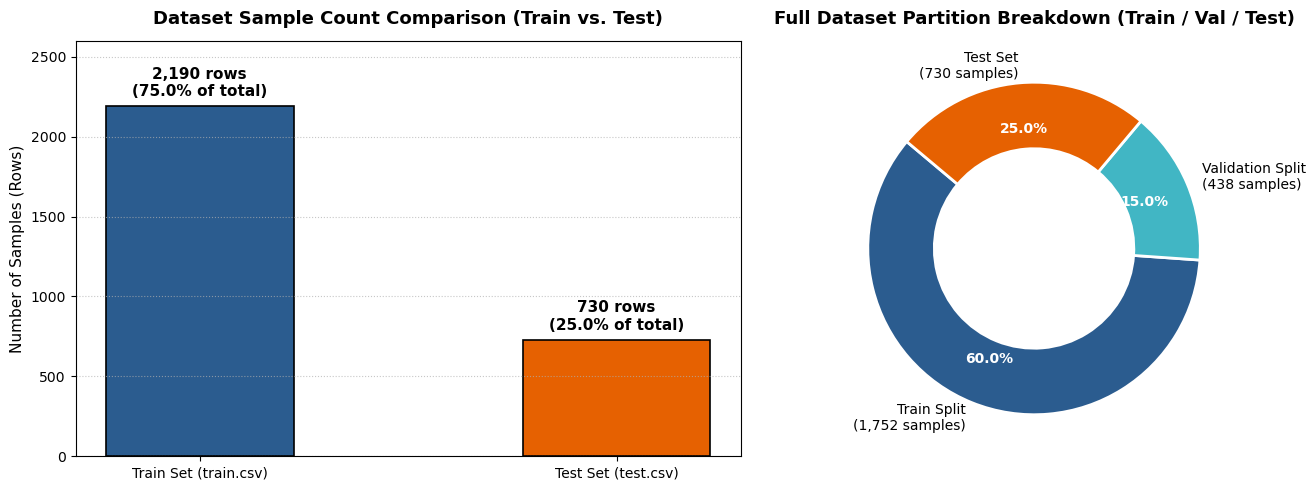

In [3]:
# Dataset shape visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar Chart of Sample Counts (Train vs. Test)
colors = ['#2B5C8F', '#E66101']
bars = ax1.bar(['Train Set (train.csv)', 'Test Set (test.csv)'], 
               [len(train_df), len(test_df)], 
               color=colors, width=0.45, edgecolor='black', linewidth=1.2)

ax1.set_title('Dataset Sample Count Comparison (Train vs. Test)', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Number of Samples (Rows)', fontsize=11)
ax1.set_ylim([0, 2600])
ax1.grid(axis='y', linestyle=':', alpha=0.7)

total_samples = len(train_df) + len(test_df)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_samples) * 100
    ax1.annotate(f'{height:,} rows\n({percentage:.1f}% of total)',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Donut Chart showing Train vs Validation vs Test Split Partitioning
val_size = int(len(train_df) * 0.2)
train_split_size = len(train_df) - val_size
test_size = len(test_df)

split_sizes = [train_split_size, val_size, test_size]
split_labels = [f'Train Split\n({train_split_size:,} samples)', 
                f'Validation Split\n({val_size:,} samples)', 
                f'Test Set\n({test_size:,} samples)']
split_colors = ['#2B5C8F', '#41B6C4', '#E66101']

wedges, texts, autotexts = ax2.pie(
    split_sizes, 
    labels=split_labels, 
    autopct='%1.1f%%',
    pctdistance=0.72,
    startangle=140, 
    colors=split_colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

plt.setp(autotexts, size=10, weight="bold", color="white")
ax2.set_title('Full Dataset Partition Breakdown (Train / Val / Test)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()


## 3. Exploratory Data Analysis (EDA) & Visualizations
Let's visualize the target class distribution, feature distributions, and the correlation structure.

### Reading the Target Distribution
This chart shows whether the classes are balanced or imbalanced. In binary classification, class imbalance matters because a model can look accurate while still failing to detect the minority class well.
We use this plot to judge whether ROC AUC, precision, recall, and confusion matrices will be more informative than accuracy alone when comparing models.

### Target Class Distribution
We inspect the distribution of the target class (`rainfall`) in the training dataset to check for imbalance.


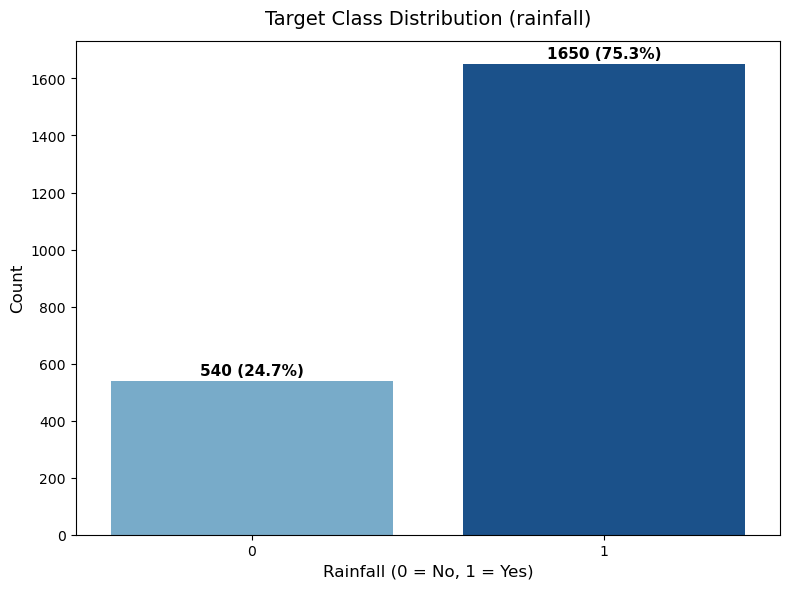

In [4]:
# Target distribution only
fig, ax = plt.subplots(figsize=(8, 6))

# Custom rain-themed palette (Light Blue for No Rain, Deep Blue for Rain)
target_colors = ['#6BAED6', '#08519C']
sns.countplot(x='rainfall', data=train_df, ax=ax, palette=target_colors, hue='rainfall', legend=False)

ax.set_title('Target Class Distribution (rainfall)', fontsize=14, pad=12)
ax.set_xlabel('Rainfall (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

total = len(train_df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + 20,
                f'{int(height)} ({height/total:.1%})', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


### Correlation Matrix Heatmap
We visualize the linear correlation coefficients between all numerical features to detect multicollinearity.


### How to Read the Correlation Heatmap
A correlation heatmap summarizes the linear relationship between pairs of numerical variables. Values close to 1 or -1 indicate a strong positive or negative relationship, while values near 0 suggest little linear dependence.
This helps us identify potentially redundant features and gives a quick view of which weather measurements may move together. That matters for both interpretation and model stability.

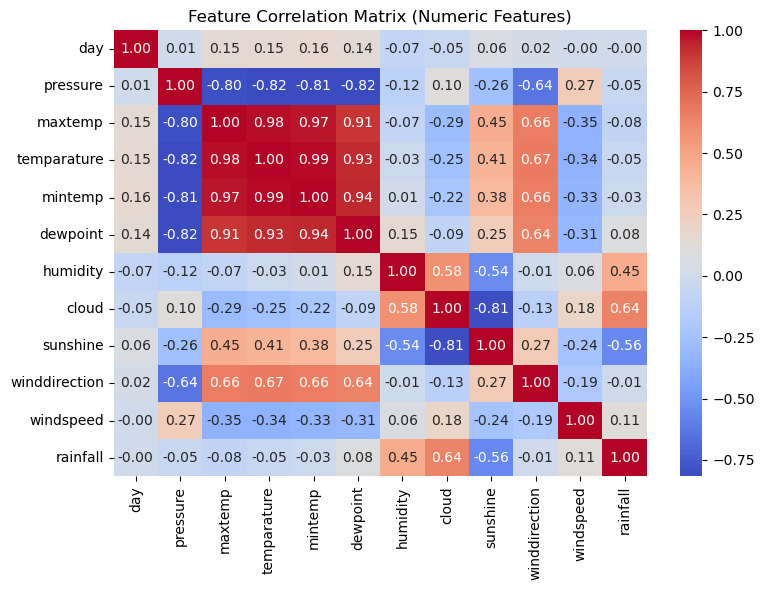

In [5]:
# Correlation matrix only (numeric features)
numeric_df = train_df.select_dtypes(include=['float64', 'int64']).drop(columns=['id'])

fig, ax = plt.subplots(figsize=(8, 6))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, cbar=True)
ax.set_title('Feature Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

### Feature Probability Distributions (Train vs. Test)
We compare the density distributions of the numerical features in the train and test splits to verify they are identically distributed.


### Why Compare Train and Test Distributions
These density plots check whether the training and test datasets come from similar distributions. If a feature looks very different between train and test, that can create a distribution shift and reduce model performance on unseen data.
For a Kaggle-style competition, this comparison is useful because the test set usually follows the same hidden generation process as the training data. Large mismatches can suggest outliers, missing preprocessing, or feature leakage concerns.

C:\Users\Lakshitha Perera\AppData\Local\Temp\ipykernel_20144\1074259004.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_df[feat], ax=axes[i], label='Train', color='blue', shade=True, alpha=0.3)
C:\Users\Lakshitha Perera\AppData\Local\Temp\ipykernel_20144\1074259004.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test_df[feat], ax=axes[i], label='Test', color='orange', shade=True, alpha=0.3)
C:\Users\Lakshitha Perera\AppData\Local\Temp\ipykernel_20144\1074259004.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_df[feat], ax=axes[i], label='Train', color='blue', shade=True, alpha=0.3)
C:\Users\Lakshit

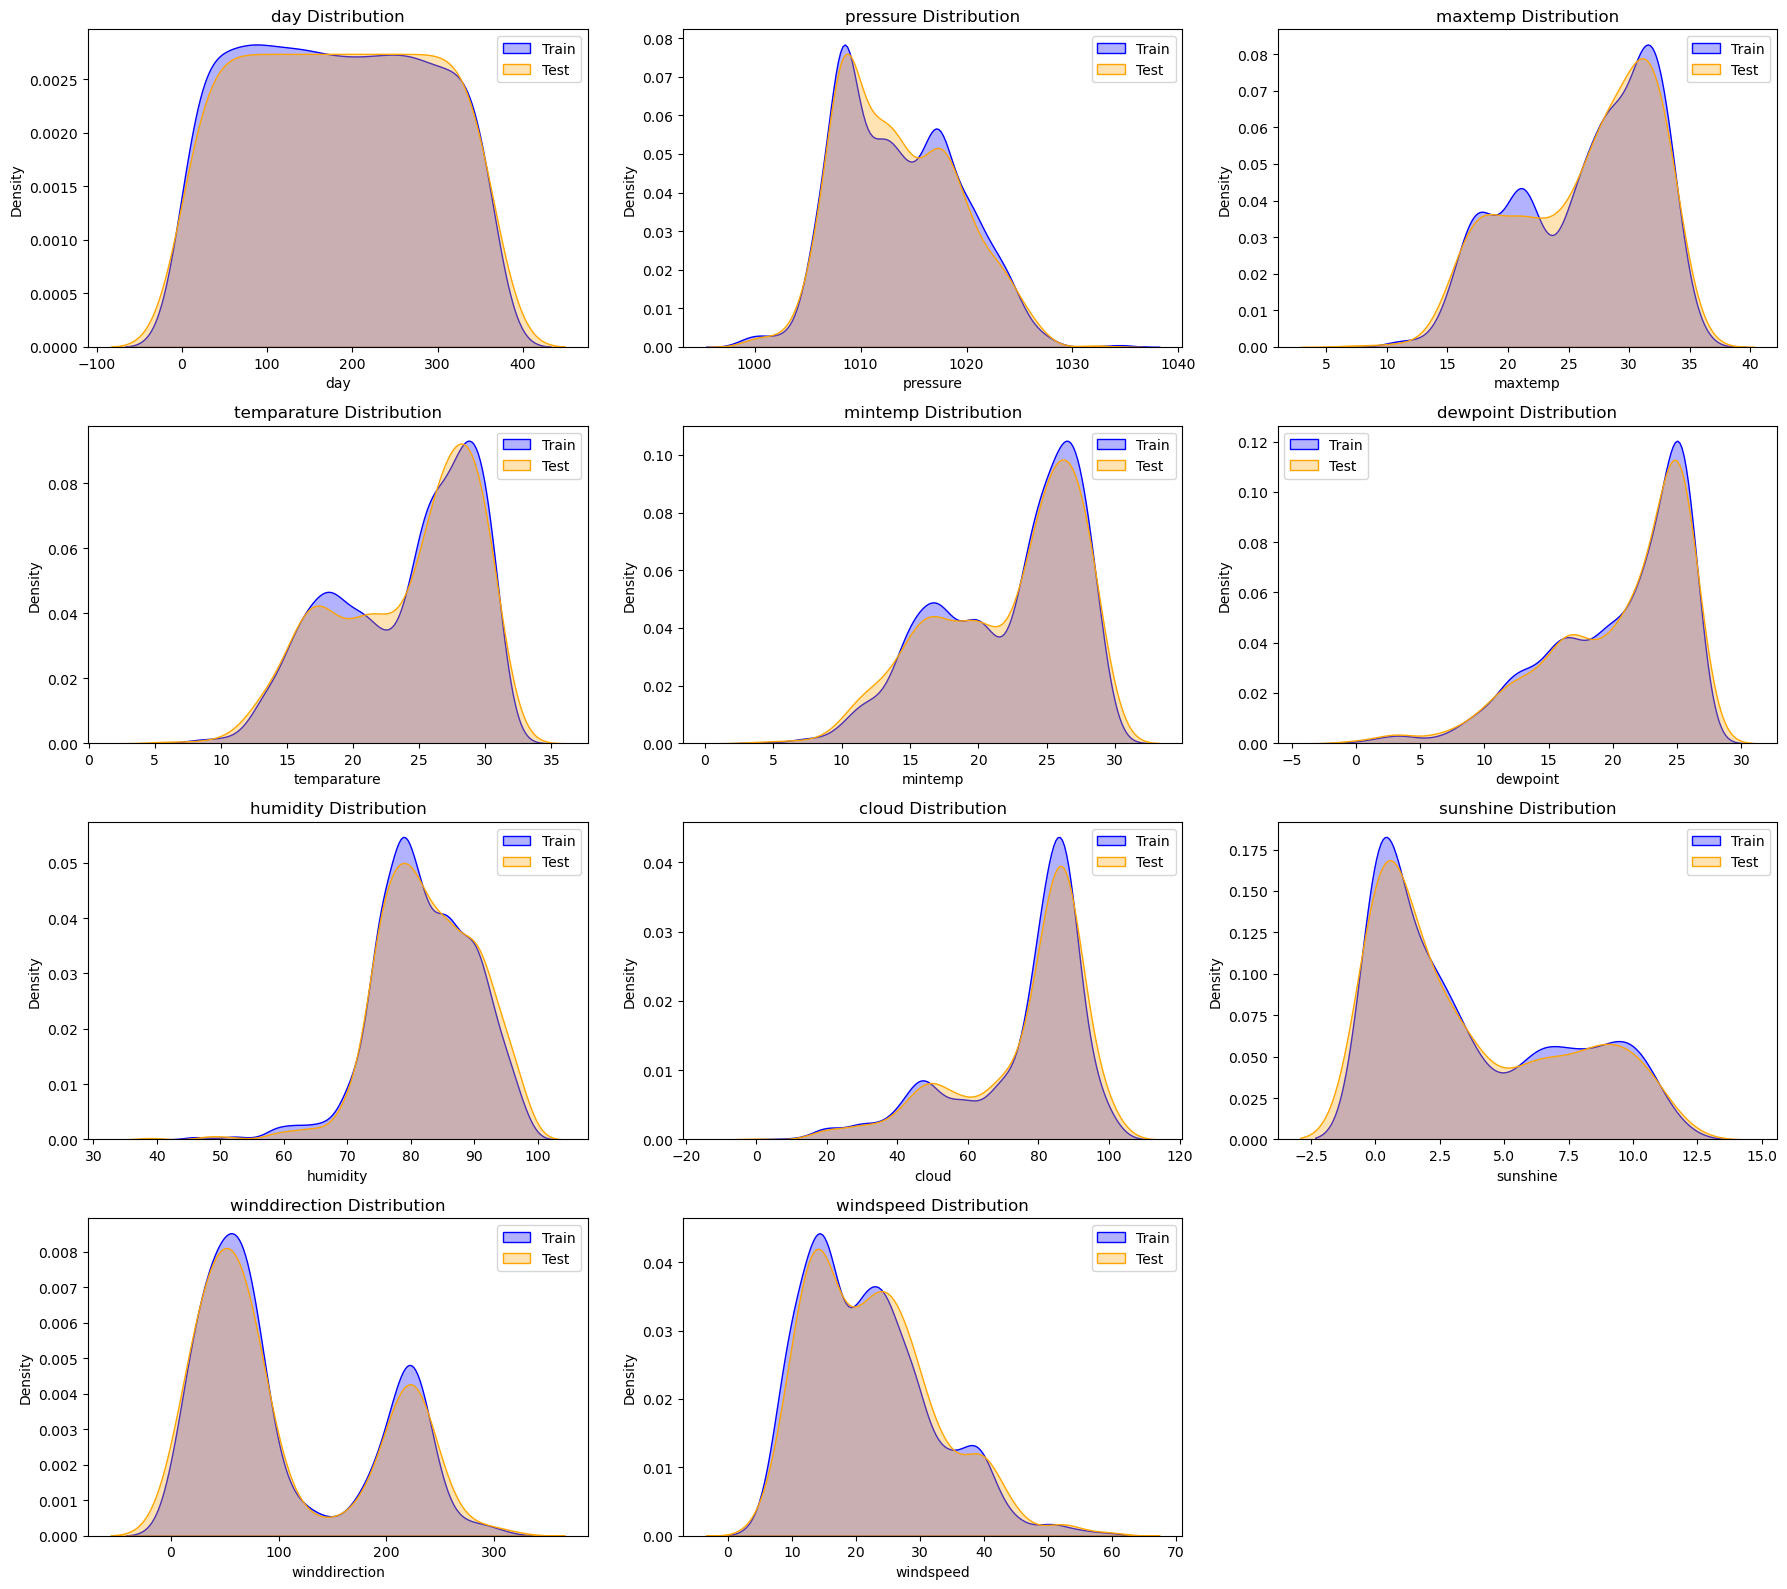

In [6]:
# Compare train and test distributions for numerical features
features = [c for c in train_df.columns if c not in ['id', 'rainfall']]
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.kdeplot(train_df[feat], ax=axes[i], label='Train', color='blue', shade=True, alpha=0.3)
    sns.kdeplot(test_df[feat], ax=axes[i], label='Test', color='orange', shade=True, alpha=0.3)
    axes[i].set_title(f'{feat} Distribution')
    axes[i].legend()

# Hide extra subplots if any
for j in range(len(features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Key Features vs. Target variable
We analyze how the key features vary across positive and negative class label groups using boxplots.


### Why We Use Boxplots Here
Boxplots show the median, spread, and outliers of each feature for the rain and no-rain classes. They are a compact way to see whether a variable behaves differently across the two target groups.
If the boxes are clearly separated or shifted, the feature is likely useful for classification because the model can use that difference to split the classes more effectively.

C:\Users\Lakshitha Perera\AppData\Local\Temp\ipykernel_20144\2782311101.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rainfall', y=feat, data=train_df, ax=axes[i], palette='Set2')
C:\Users\Lakshitha Perera\AppData\Local\Temp\ipykernel_20144\2782311101.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rainfall', y=feat, data=train_df, ax=axes[i], palette='Set2')
C:\Users\Lakshitha Perera\AppData\Local\Temp\ipykernel_20144\2782311101.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rainfall', y=feat, data=train_df, ax=axes[

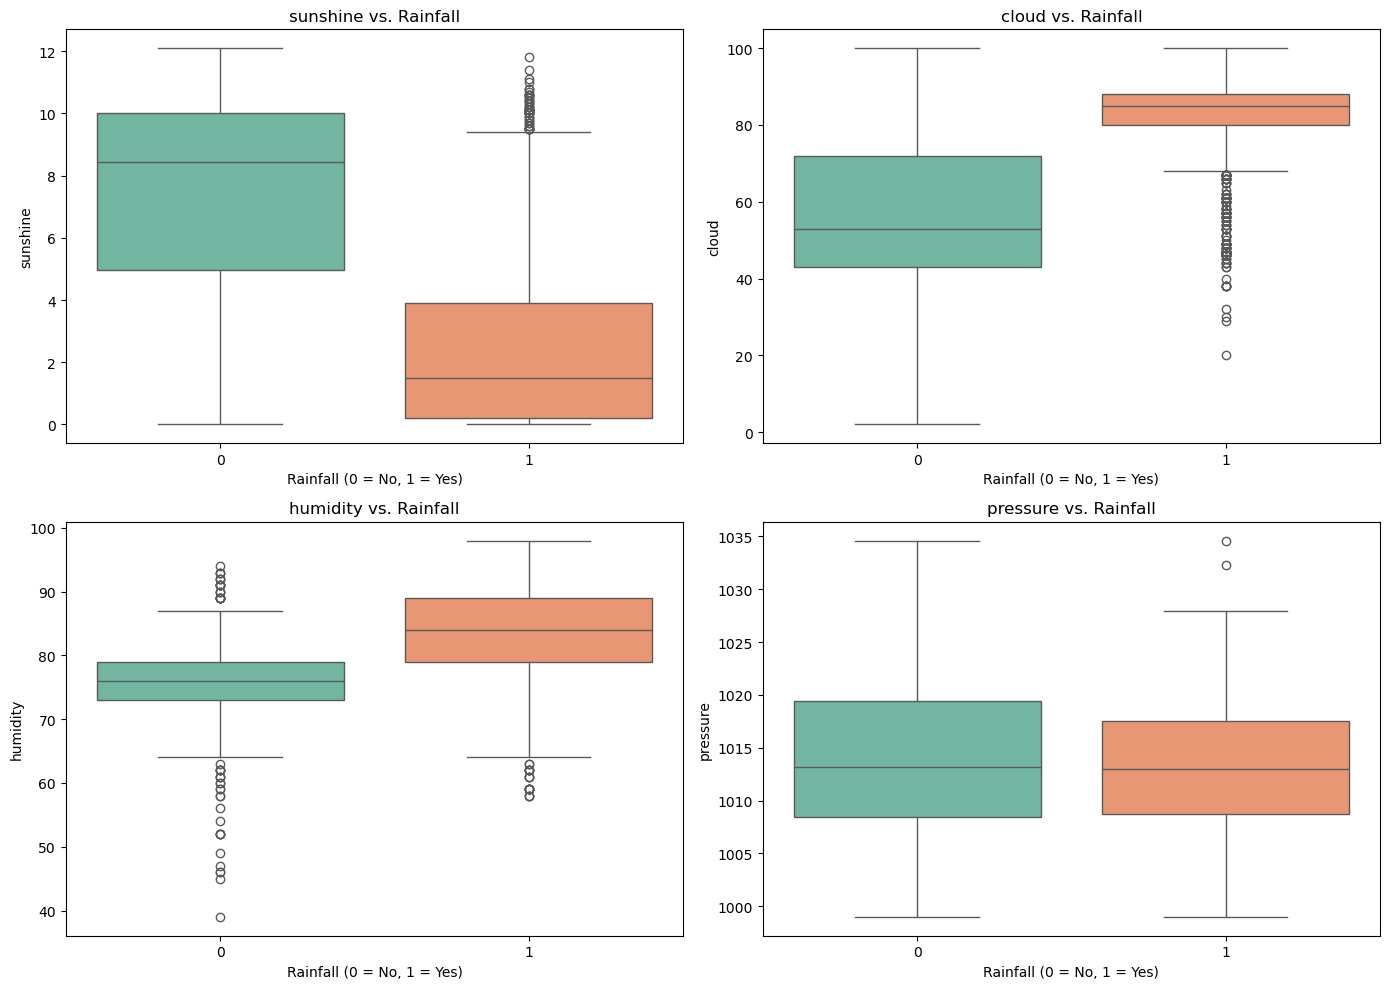

In [7]:
# Relationship of key features with the target (rainfall)
key_features = ['sunshine', 'cloud', 'humidity', 'pressure']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(x='rainfall', y=feat, data=train_df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feat} vs. Rainfall')
    axes[i].set_xlabel('Rainfall (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

### Feature Engineering Function Definition
We define a robust engineering pipeline to impute missing values using median values and build new meteorological features.


### Why We Engineer New Features
Raw weather measurements are useful, but models often perform better when we add derived features that capture relationships between them. For example, temperature range, dew point depression, and sunshine-to-cloud ratio can reveal patterns that are harder for the model to discover directly from the original columns.
We also fill missing values with training medians so the model sees a complete feature matrix. Using medians is a simple and robust strategy because it is less sensitive to extreme values than the mean.

In [8]:
def engineer_features(df, train_medians=None):
    df_feat = df.copy()

    # Handle missing values using provided training medians
    if train_medians is not None:
        for col in df_feat.columns:
            if df_feat[col].isnull().sum() > 0:
                df_feat[col] = df_feat[col].fillna(train_medians[col])
    
    # Existing features
    df_feat['temp_range'] = df_feat['maxtemp'] - df_feat['mintemp']
    df_feat['dewpoint_depression'] = df_feat['temparature'] - df_feat['dewpoint']
    df_feat['sunshine_cloud_ratio'] = df_feat['sunshine'] / (df_feat['cloud'] + 1.0)
    df_feat['humidity_cloud_interaction'] = (df_feat['humidity'] / 100.0) * (df_feat['cloud'] / 100.0)
    df_feat['temp_dewpoint_ratio'] = df_feat['dewpoint'] / (df_feat['temparature'] + 1.0)
    df_feat['wind_power'] = df_feat['windspeed'] * df_feat['pressure']
    df_feat['sunshine_humidity_diff'] = df_feat['sunshine'] - (df_feat['humidity'] / 10.0)

    # New: Cyclical encoding for day (seasonality)
    df_feat['day_sin'] = np.sin(2 * np.pi * df_feat['day'] / 365)
    df_feat['day_cos'] = np.cos(2 * np.pi * df_feat['day'] / 365)

    return df_feat

### Apply Feature Engineering
We apply the engineering function to the train and test dataframes, extracting targets and dropping unnecessary columns.


### What Happens in the Feature Engineering Step
This step turns the raw train and test tables into model-ready feature matrices. We create interaction-style variables, seasonal encodings from the day of year, and a few ratio-based features that can help separate rainy from dry conditions.
The same transformation is applied to both train and test data so the model always sees the same feature structure at training time and prediction time.

In [9]:
# Get medians from train set for safe imputation
medians = train_df.median()

# Apply feature engineering
X_train = engineer_features(train_df, train_medians=medians)
X_test = engineer_features(test_df, train_medians=medians)

# Extract target and drop non-predictive columns
y_train = X_train['rainfall']
X_train = X_train.drop(columns=['id', 'rainfall'])
X_test_ids = X_test['id']
X_test = X_test.drop(columns=['id'])

# Optional: You can also drop 'day' now since we have sin/cos
# X_train = X_train.drop(columns=['day'])
# X_test = X_test.drop(columns=['day'])

print(f'Engineered features Train shape: {X_train.shape}')
print(f'Engineered features Test shape: {X_test.shape}')
display(X_train.head())

Engineered features Train shape: (2190, 20)
Engineered features Test shape: (730, 20)


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,temp_range,dewpoint_depression,sunshine_cloud_ratio,humidity_cloud_interaction,temp_dewpoint_ratio,wind_power,sunshine_humidity_diff,day_sin,day_cos
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1.3,1.2,0.012360,0.7656,0.898148,17499.28,-7.6,0.017213,0.999852
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,0.4,1.5,0.000000,0.8645,0.860335,22327.05,-9.5,0.034422,0.999407
2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,4.8,6.8,0.172917,0.3525,0.543860,18536.21,0.8,0.051620,0.998667
3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1.2,1.0,0.000000,0.9025,0.893617,36077.04,-9.5,0.068802,0.997630
4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,6.1,8.8,0.078261,0.2340,0.494845,25340.64,-1.6,0.085965,0.996298


## 4. Train / Validation Split

### Why We Split Into Train and Validation Sets
A separate validation set gives us an honest estimate of how the model might perform on unseen data. The training set is used to learn patterns, while the validation set is held back for evaluation.
Stratification is important here because it preserves the rain/no-rain class ratio in both splits, making the comparison fair and more reliable.

In [10]:
RANDOM_STATE = 42

# Split the data into train and validation sets (80% train, 20% validation)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Train features shape: {X_train_split.shape}, Label shape: {y_train_split.shape}")
print(f"Validation features shape: {X_val.shape}, Label shape: {y_val.shape}")

Train features shape: (1752, 20), Label shape: (1752,)
Validation features shape: (438, 20), Label shape: (438,)


## Model 1: Random Forest

### Why Random Forest Is a Good Baseline
Random Forest combines many decision trees trained on different bootstrap samples and feature subsets. The averaging effect usually makes it more stable than a single tree and helps reduce overfitting.
We use it as a strong baseline because it works well on tabular data, handles nonlinear relationships, and gives a useful feature-importance ranking.

In [11]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    min_samples_split=5,
    max_depth=15,
    n_jobs=-1
)

# Train the model on the split training set
rf_model.fit(X_train_split, y_train_split)

# Predict probabilities and class labels on the validation set
y_val_pred_proba = rf_model.predict_proba(X_val)[:, 1]
y_val_pred = rf_model.predict(X_val)

# Calculate validation ROC AUC score
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)
print(f"Validation ROC AUC Score: {val_roc_auc:.5f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))



Validation ROC AUC Score: 0.86911

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.64      0.70       108
           1       0.89      0.94      0.91       330

    accuracy                           0.86       438
   macro avg       0.83      0.79      0.80       438
weighted avg       0.86      0.86      0.86       438



### Random Forest ROC Curve
We plot the Receiver Operating Characteristic (ROC) curve to assess the true positive rate versus false positive rate trade-off.


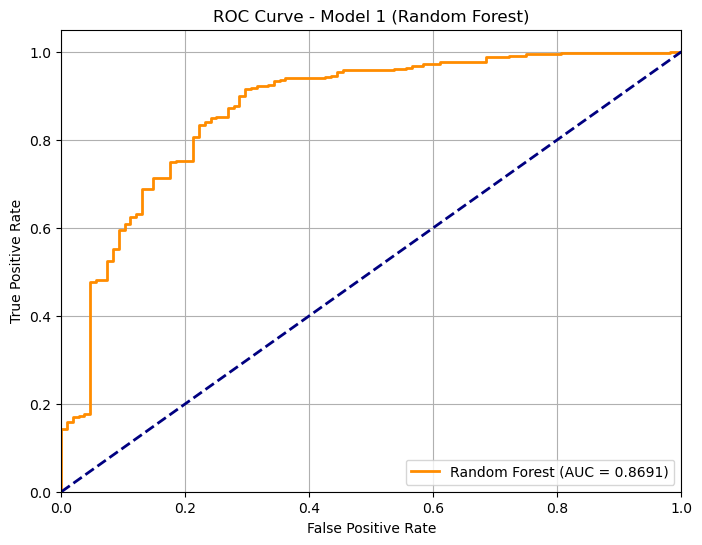

In [12]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {val_roc_auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Quality / Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model 1 (Random Forest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### How to Read the ROC Curve
A ROC curve compares the true positive rate against the false positive rate across all thresholds. Curves that bend toward the top-left corner indicate better discrimination between the two classes.
The AUC value shown in the legend summarizes the curve into one number. An AUC closer to 1.0 means stronger ranking ability, while 0.5 means the model is behaving like random chance.

### Feature Importance & Model Saving
Below we extract and visualize the feature importances of our Random Forest model to understand the most predictive meteorological indicators. We also save the trained model to disk for future inference.

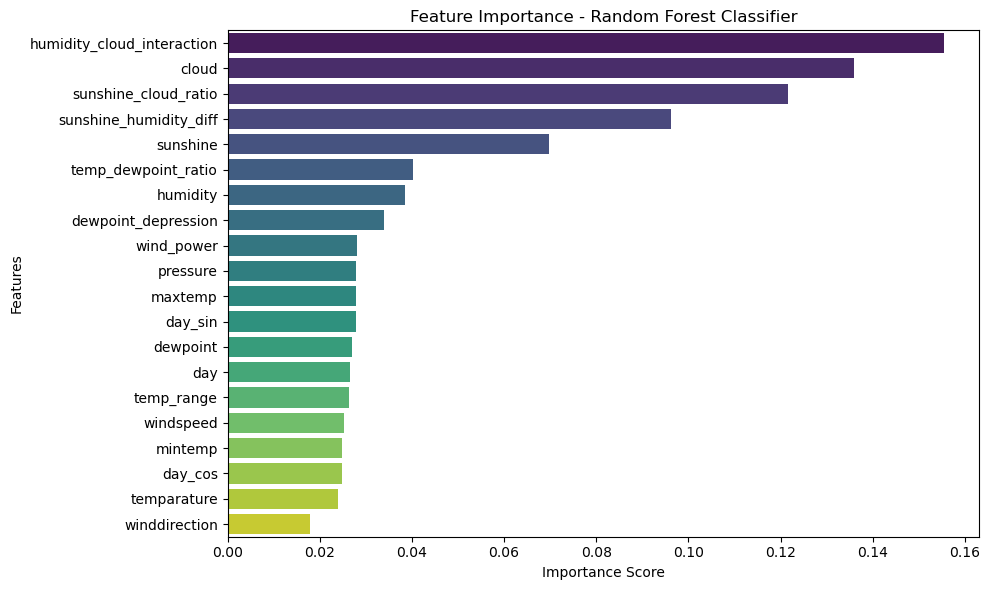

Feature Importances:
                   Feature  Importance
humidity_cloud_interaction    0.155352
                     cloud    0.135841
      sunshine_cloud_ratio    0.121642
    sunshine_humidity_diff    0.096217
                  sunshine    0.069811
       temp_dewpoint_ratio    0.040186
                  humidity    0.038607
       dewpoint_depression    0.033996
                wind_power    0.028034
                  pressure    0.027968
                   maxtemp    0.027944
                   day_sin    0.027891
                  dewpoint    0.026954
                       day    0.026526
                temp_range    0.026310
                 windspeed    0.025241
                   mintemp    0.024859
                   day_cos    0.024781
               temparature    0.023956
             winddirection    0.017883


In [13]:
# Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame to store feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance - Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Display feature importances in text format
print("Feature Importances:")
print(feature_importance_df.to_string(index=False))


### How to Interpret the Feature Importance Plot
Feature importance shows which variables the Random Forest used most often to make splits that reduce impurity. Higher bars mean the model relied on that feature more heavily when separating rain from no-rain cases.
This is not a causal measure, but it is useful for understanding which weather signals appear most predictive in the trained model.

### Save Random Forest Model
We serialize the trained Random Forest model to the models folder using `joblib`.


In [14]:
# Save the trained model to a file
model_filename = 'models/random_forest_model.joblib'
joblib.dump(rf_model, model_filename)
print(f"\nModel successfully saved to '{model_filename}'!")


Model successfully saved to 'models/random_forest_model.joblib'!


## Model 2: Decision Tree
We instantiate a Decision Tree Classifier, train it on the split training data, evaluate its ROC AUC performance on the validation split, analyze its feature importances, and save the model to disk.

### Why We Also Try a Decision Tree
A single decision tree is easy to explain because every prediction follows a sequence of if/else splits. That makes it useful for interpretation, even though it can overfit more easily than ensemble methods.
By comparing it with Random Forest, we can see how much performance comes from ensembling rather than from the feature set alone.

### Decision Tree Model Training & Evaluation
We import DecisionTreeClassifier, instantiate it with hyper-parameters to control overfitting, fit it on the training split, and evaluate its ROC AUC score and classification report on the validation split.

In [15]:
# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

# Train the model on the split training set
dt_model.fit(X_train_split, y_train_split)

# Predict probabilities and class labels on the validation set
y_val_pred_proba_dt = dt_model.predict_proba(X_val)[:, 1]
y_val_pred_dt = dt_model.predict(X_val)

# Calculate validation ROC AUC score
val_roc_auc_dt = roc_auc_score(y_val, y_val_pred_proba_dt)
print(f"Validation ROC AUC Score (Decision Tree): {val_roc_auc_dt:.5f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_dt))




Validation ROC AUC Score (Decision Tree): 0.80035

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.58      0.61       108
           1       0.87      0.89      0.88       330

    accuracy                           0.82       438
   macro avg       0.76      0.74      0.75       438
weighted avg       0.81      0.82      0.81       438



### Decision Tree ROC Curve
We plot the ROC curve for our Decision Tree model to visually evaluate its predictive performance.


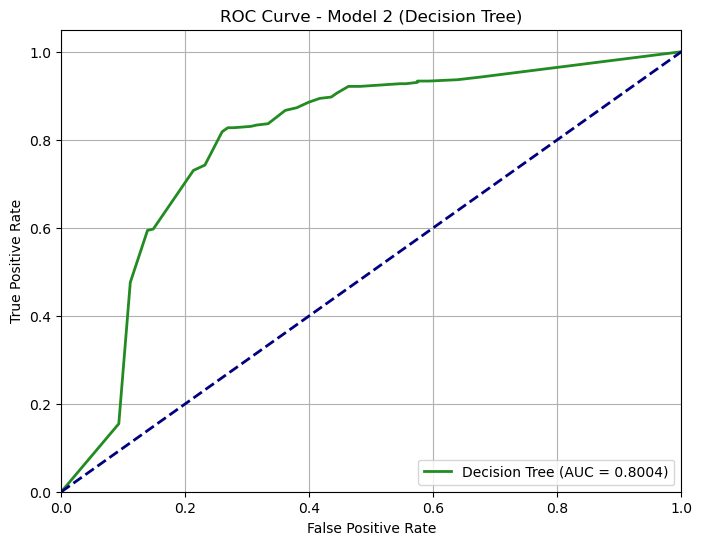

In [16]:
# Plot ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_val, y_val_pred_proba_dt)
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {val_roc_auc_dt:.4f})', color='forestgreen', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model 2 (Decision Tree)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Decision Tree Feature Importances
We retrieve the relative importance scores of the features according to the Decision Tree split rules.


In [17]:
# Get feature importances from the trained Decision Tree model
importances_dt = dt_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame to store feature importances
feature_importance_dt_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_dt
}).sort_values(by='Importance', ascending=False)

# Display feature importances in text format
print("Decision Tree Feature Importances:")
print(feature_importance_dt_df.to_string(index=False))


Decision Tree Feature Importances:
                   Feature  Importance
humidity_cloud_interaction    0.640287
      sunshine_cloud_ratio    0.064946
       temp_dewpoint_ratio    0.060020
       dewpoint_depression    0.043456
                temp_range    0.023337
                   mintemp    0.023081
    sunshine_humidity_diff    0.019353
                  dewpoint    0.016789
                     cloud    0.012915
                       day    0.012082
                  humidity    0.012037
                   day_cos    0.012008
                  pressure    0.011812
                   day_sin    0.011147
             winddirection    0.010450
                wind_power    0.010121
               temparature    0.008801
                 windspeed    0.007358
                  sunshine    0.000000
                   maxtemp    0.000000


### Visualize Decision Tree Feature Importances
We plot the relative importances of the features to understand which features were used most for partitioning data.


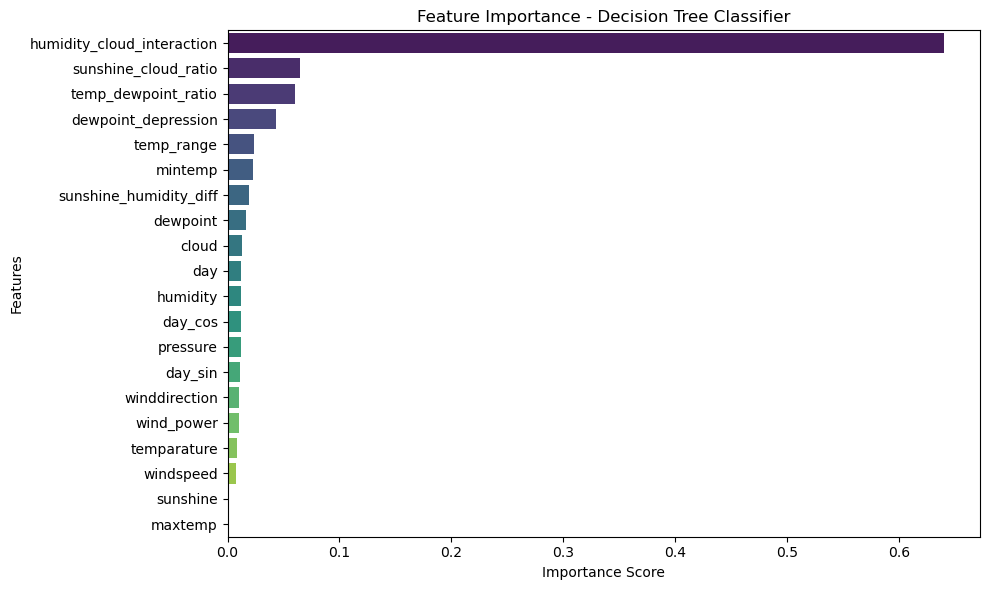

In [18]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_dt_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance - Decision Tree Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Visualize Decision Tree Architecture
We plot the tree diagram of the trained Decision Tree model (`dt_model`) using `sklearn.tree.plot_tree`. To ensure maximum visual clarity and readability, we display the top 3 levels of splits, illustrating feature decision thresholds, Gini impurity values, sample node counts, and class distributions.

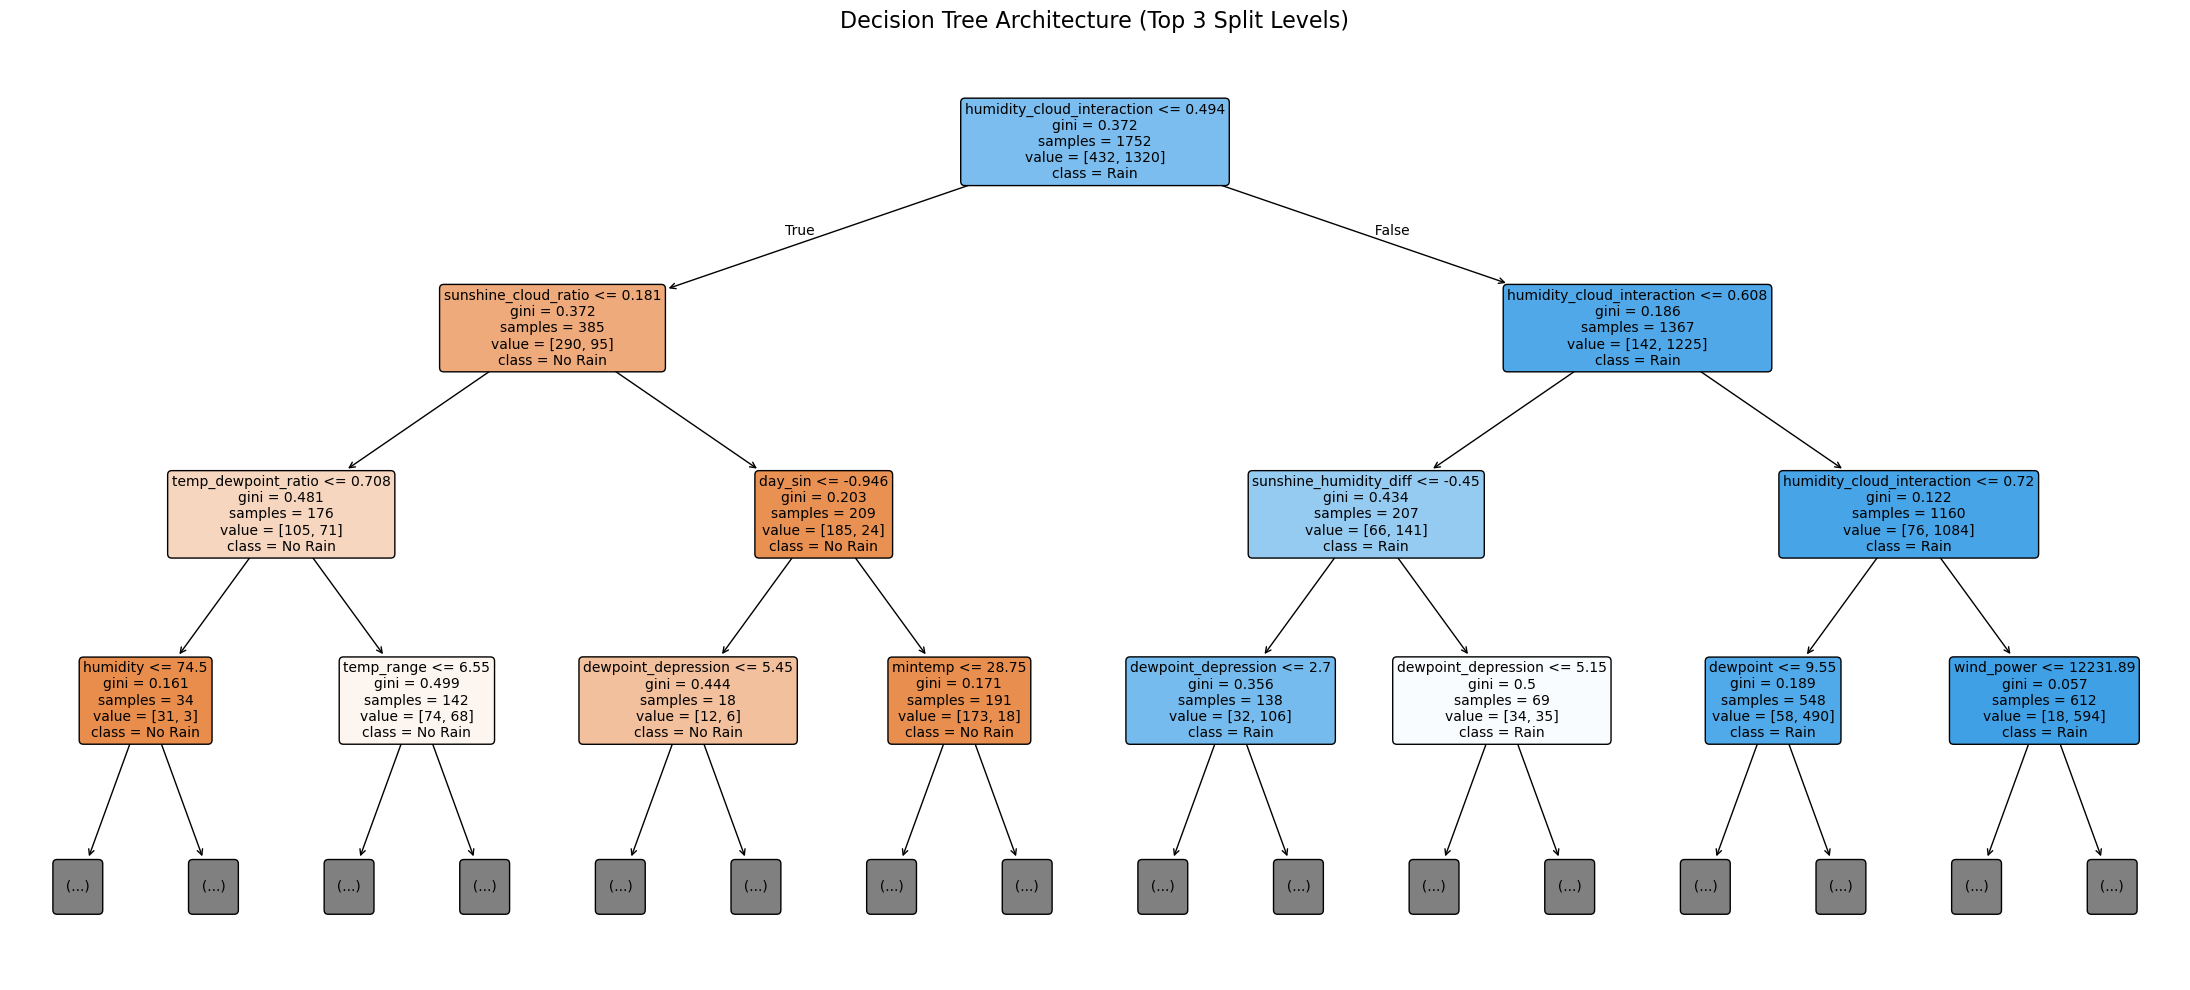

In [19]:
# Plot Decision Tree Diagram (top 3 levels for high readability)
plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['No Rain', 'Rain'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title('Decision Tree Architecture (Top 3 Split Levels)', fontsize=16, pad=15)
plt.tight_layout()
plt.show()


### Save Decision Tree Model
We serialize the trained Decision Tree model to a joblib file for reuse.


In [20]:
# Ensure directory exists and save the trained model to a file
os.makedirs('models', exist_ok=True)
model_filename_dt = 'models/decision_tree_model.joblib'
joblib.dump(dt_model, model_filename_dt)
print(f"\nDecision Tree model successfully saved to '{model_filename_dt}'!")


Decision Tree model successfully saved to 'models/decision_tree_model.joblib'!


## Model 3: XGBoost
XGBoost (Extreme Gradient Boosting) is a powerful gradient-boosted decision tree algorithm known for its speed and performance in structured/tabular data competitions. We train an XGBClassifier, evaluate it on the validation split, visualize its ROC curve and feature importances, and save the model.

### Why XGBoost Often Performs Best on Tabular Data
XGBoost is a gradient boosting method that builds trees sequentially, with each new tree trying to correct the mistakes made by the previous ones. This makes it especially powerful for structured data where small interactions matter.
The regularization terms and learning rate help control overfitting, which is why XGBoost is often a strong competition model for tabular prediction tasks.

### XGBoost Model Training & Evaluation
We instantiate the XGBClassifier with tuned hyperparameters, fit it on the training split, and evaluate using ROC AUC and a classification report on the validation split.

In [21]:
# Initialize the Tuned XGBoost model for optimal performance on small tabular dataset
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=3.0,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

# Train the model on the split training set
xgb_model.fit(X_train_split, y_train_split)

# Predict probabilities and class labels on the validation set
y_val_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred_xgb = xgb_model.predict(X_val)

# Calculate validation ROC AUC score
val_roc_auc_xgb = roc_auc_score(y_val, y_val_pred_proba_xgb)
print(f"Validation ROC AUC Score (XGBoost): {val_roc_auc_xgb:.5f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb))


Validation ROC AUC Score (XGBoost): 0.88120

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.61      0.69       108
           1       0.88      0.95      0.91       330

    accuracy                           0.87       438
   macro avg       0.84      0.78      0.80       438
weighted avg       0.86      0.87      0.86       438



### XGBoost ROC Curve
We plot the Receiver Operating Characteristic (ROC) curve for the XGBoost model to visually evaluate its discriminative power.

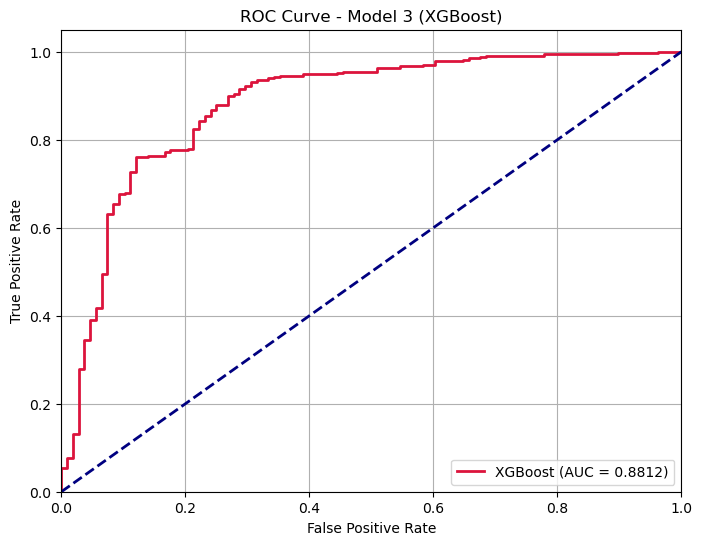

In [22]:
# Plot ROC Curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_val_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {val_roc_auc_xgb:.4f})', color='crimson', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model 3 (XGBoost)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### XGBoost Feature Importances
We extract the feature importances from the XGBoost model and display them in both tabular and visual formats.

In [23]:
# Get feature importances from the trained XGBoost model
importances_xgb = xgb_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame to store feature importances
feature_importance_xgb_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

# Display feature importances in text format
print("XGBoost Feature Importances:")
print(feature_importance_xgb_df.to_string(index=False))


XGBoost Feature Importances:
                   Feature  Importance
humidity_cloud_interaction    0.253522
                     cloud    0.235872
    sunshine_humidity_diff    0.116135
      sunshine_cloud_ratio    0.062926
                  sunshine    0.039262
               temparature    0.035679
                  dewpoint    0.025806
                   maxtemp    0.025000
                  humidity    0.024689
       temp_dewpoint_ratio    0.024462
       dewpoint_depression    0.022792
                   mintemp    0.020888
             winddirection    0.019562
                  pressure    0.017301
                wind_power    0.016455
                 windspeed    0.014653
                   day_cos    0.012796
                   day_sin    0.012416
                       day    0.011156
                temp_range    0.008630


### Visualize XGBoost Feature Importances
We generate a horizontal bar chart to visualize which features contribute most to the XGBoost model's predictions.

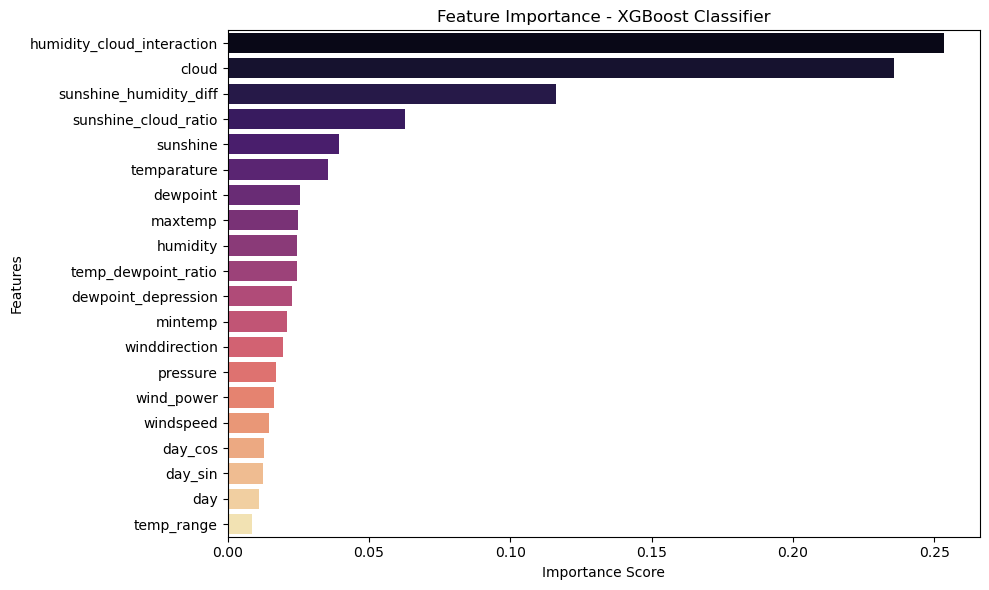

In [24]:
# Plot Feature Importance for XGBoost
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb_df, palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance - XGBoost Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


### Save XGBoost Model
We serialize the trained XGBoost model to a joblib file for future inference.

In [25]:
# Ensure directory exists and save the trained XGBoost model
os.makedirs('models', exist_ok=True)
model_filename_xgb = 'models/xgboost_model.joblib'
joblib.dump(xgb_model, model_filename_xgb)
print(f"XGBoost model successfully saved to '{model_filename_xgb}'!")


XGBoost model successfully saved to 'models/xgboost_model.joblib'!


## Model 4: Neural Network (TensorFlow / Keras)
In this section, we build and train a **Deep Neural Network (DNN)** using **TensorFlow / Keras**. Neural Networks are powerful non-linear function approximators. Because artificial neural networks are sensitive to feature magnitude differences, we first normalize the features using `StandardScaler` fitted on the training split.

### Feature Scaling & Scaler Persistence
We fit `StandardScaler` on `X_train_split` and transform `X_train_split`, `X_val`, and `X_test`. We serialize the fitted `StandardScaler` to `models/nn_scaler.joblib` for reproducible inference on raw unscaled data.

### Why Scaling Is Needed for the Neural Network
Neural networks train best when input features are on a similar scale. Without scaling, large-valued columns can dominate the gradients and make optimization less stable.
Standardization centers each feature and scales it to unit variance, which usually helps the network learn faster and more reliably on tabular data.

In [26]:
# Initialize and fit StandardScaler on training split
scaler = StandardScaler()
X_train_split_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Ensure directory exists and save the fitted scaler
os.makedirs('models', exist_ok=True)
scaler_filename = 'models/nn_scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f"StandardScaler successfully saved to '{scaler_filename}'!")


StandardScaler successfully saved to 'models/nn_scaler.joblib'!


### Neural Network Architecture
We build a compact, heavily regularized Multi-Layer Perceptron (MLP) architecture specifically designed to prevent overfitting on the small tabular dataset (1,752 training samples). The key design decisions are:

**Architecture (Compact & Regularized):**
- **Layer 1**: `Dense(32)` with `ReLU` activation and `L2(0.015)` weight penalty — limits the model's capacity to memorize noise
- **BatchNormalization** after each dense layer — stabilizes and accelerates training by normalizing internal activations
- **Dropout(0.35 / 0.25)** — randomly disables 35% and 25% of neurons per training step, forcing the network to learn distributed, redundant representations
- **Layer 2**: `Dense(16)` with `ReLU` and `L2(0.015)`
- **Layer 3**: `Dense(8)` with `ReLU` (no regularization — lightweight feature refinement)
- **Output**: `Dense(1, sigmoid)` — outputs calibrated rainfall probability in [0, 1]

**Compilation & Loss:**
- **Optimizer**: `Adam(lr=0.001)` — adaptive gradient descent with momentum
- **Loss**: `BinaryCrossentropy(label_smoothing=0.03)` — softens hard 0/1 labels to 0.015/0.985, discouraging the network from producing overconfident extreme probabilities and reducing the incentive to overfit
- **Metrics**: Tracks `accuracy` and `AUC` (Area Under the ROC Curve) during training

**Callbacks (Early Stopping & Learning Rate Scheduling):**
- **EarlyStopping** (`monitor='val_auc'`, `patience=7`): Halts training as soon as validation AUC stops improving for 7 consecutive epochs, and restores the best checkpoint weights
- **ReduceLROnPlateau** (`monitor='val_loss'`, `patience=3`, `factor=0.5`): Halves the learning rate when validation loss plateaus, allowing finer convergence near the optimum

This combination of **compact architecture + L2 regularization + aggressive dropout + label smoothing + early stopping** collectively ensures the model generalizes well despite the limited training data.

In [27]:
# Set random seed for reproducibility
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Build Optimized Regularized Neural Network (Anti-Overfitting Architecture)
nn_model = Sequential([
    Dense(32, activation='relu', kernel_regularizer=l2(0.015), input_shape=(X_train_split_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.35),
    Dense(16, activation='relu', kernel_regularizer=l2(0.015)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model with Label Smoothing to prevent extreme probabilities
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.03),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Display architecture summary
nn_model.summary()

# Define strict EarlyStopping to halt training right when validation AUC peaks
early_stopping = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

# Fit regularized model
history = nn_model.fit(
    X_train_split_scaled,
    y_train_split,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Predict probabilities and binary labels on validation set
y_val_pred_proba_nn = nn_model.predict(X_val_scaled).ravel()
y_val_pred_nn = (y_val_pred_proba_nn >= 0.5).astype(int)

# Calculate validation ROC AUC
val_roc_auc_nn = roc_auc_score(y_val, y_val_pred_proba_nn)
print(f"\nValidation ROC AUC Score (Optimized Anti-Overfitting Neural Network): {val_roc_auc_nn:.5f}")
print("\nClassification Report (Neural Network):")
print(classification_report(y_val, y_val_pred_nn))


C:\Users\Lakshitha Perera\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4361 - auc: 0.6480 - loss: 1.5534 - val_accuracy: 0.4361 - val_auc: 0.7185 - val_loss: 1.3688 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6307 - auc: 0.7649 - loss: 1.2968 - val_accuracy: 0.7511 - val_auc: 0.7947 - val_loss: 1.2079 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7380 - auc: 0.7957 - loss: 1.1570 - val_accuracy: 0.8174 - val_auc: 0.8141 - val_loss: 1.0925 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7842 - auc: 0.8017 - loss: 1.0647 - val_accuracy: 0.8447 - val_auc: 0.8376 - val_loss: 0.9909 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8191 - auc: 0.8309 - loss: 0.9580 - val_accuracy: 0.8425 - val_auc: 0.8531 - val_loss: 0.9049 - learning_rate: 0.0010
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8425 - auc: 0.8493 - loss

### Visualize Neural Network Training Curves
We inspect loss and ROC AUC progression over training epochs to ensure stable optimization.

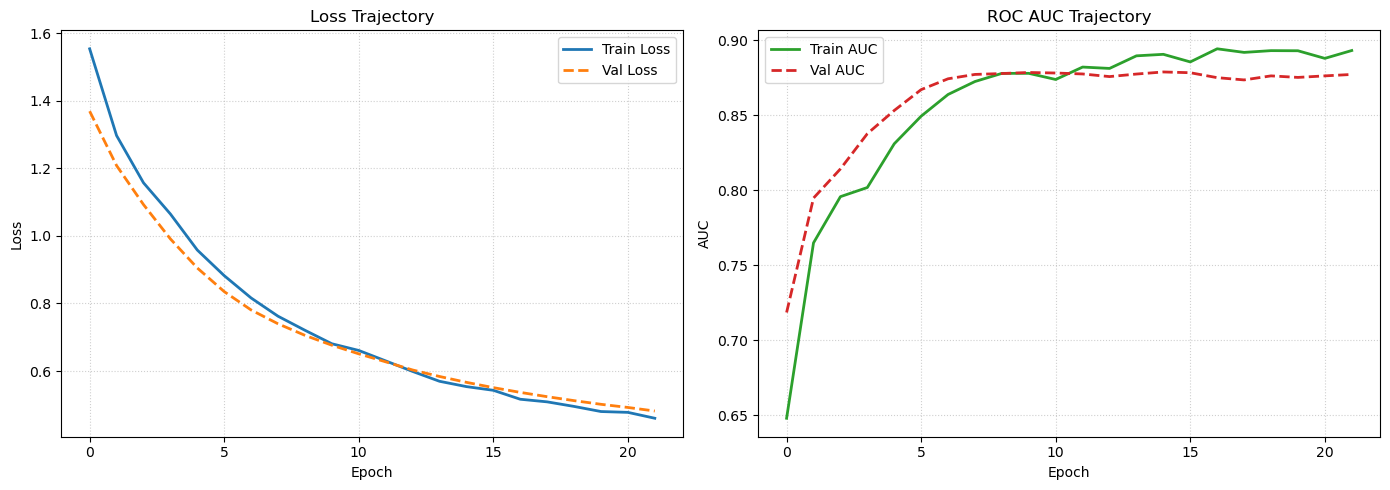

In [28]:
# Plot Loss & AUC curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss', color='#1f77b4', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2, linestyle='--')
ax1.set_title('Loss Trajectory', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(history.history['auc'], label='Train AUC', color='#2ca02c', lw=2)
ax2.plot(history.history['val_auc'], label='Val AUC', color='#d62728', lw=2, linestyle='--')
ax2.set_title('ROC AUC Trajectory', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### What the Training Curves Tell Us
The loss curve shows whether the optimizer is still improving the fit to the data, while the AUC curve shows how well the model ranks rainy days above dry days during training and validation.
If training performance keeps improving but validation performance stalls or drops, that is a sign of overfitting. The second neural-network pass in this notebook is designed to reduce that gap.

### Overfitting Diagnosis & Fix
From the training curves above, we observe **mild overfitting**: the Train AUC keeps rising (~0.90) while the Val AUC plateaus around 0.85, and the train loss drops well below val loss. To close this gap and improve generalization, we retrain with:

| Regularization Technique | Previous | Fixed |
|:---|:---|:---|
| **Dropout Rate** | 0.35 / 0.25 | **0.45 / 0.35** |
| **L2 Weight Penalty** | 0.015 | **0.025** |
| **Label Smoothing** | 0.03 | **0.05** |
| **EarlyStopping Patience** | 7 | **5** |
| **ReduceLR Patience** | 3 | **2** |
| **Max Epochs** | 50 | **40** |
| **Architecture** | 32 → 16 → 8 | **32 → 16 → 8** (same) |

These changes increase the regularization strength to penalize overconfident weight updates, smooth noisy labels, and stop training earlier before the model memorizes training noise.

In [29]:
# Set random seed for reproducibility
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Overfitting Fix: Stronger Regularization & Earlier Stopping
nn_model = Sequential([
    Dense(32, activation='relu', kernel_regularizer=l2(0.025), input_shape=(X_train_split_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.45),
    Dense(16, activation='relu', kernel_regularizer=l2(0.025)),
    BatchNormalization(),
    Dropout(0.35),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile with increased label smoothing to prevent overconfident predictions
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

nn_model.summary()

# Tighter EarlyStopping (patience=5) to halt before overfitting gap grows
early_stopping = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# More aggressive LR reduction (patience=2)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

# Retrain with stronger regularization
history = nn_model.fit(
    X_train_split_scaled,
    y_train_split,
    validation_data=(X_val_scaled, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Re-evaluate on validation set
y_val_pred_proba_nn = nn_model.predict(X_val_scaled).ravel()
y_val_pred_nn = (y_val_pred_proba_nn >= 0.5).astype(int)

val_roc_auc_nn = roc_auc_score(y_val, y_val_pred_proba_nn)
print(f"\nValidation ROC AUC (Overfitting-Fixed NN): {val_roc_auc_nn:.5f}")
print("\nClassification Report (Overfitting-Fixed NN):")
print(classification_report(y_val, y_val_pred_nn))


C:\Users\Lakshitha Perera\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.4766 - auc: 0.6326 - loss: 2.0911 - val_accuracy: 0.6256 - val_auc: 0.7679 - val_loss: 1.7475 - learning_rate: 0.0010
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6016 - auc: 0.7315 - loss: 1.7659 - val_accuracy: 0.7922 - val_auc: 0.8269 - val_loss: 1.5489 - learning_rate: 0.0010
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7106 - auc: 0.7864 - loss: 1.5447 - val_accuracy: 0.8356 - val_auc: 0.8500 - val_loss: 1.3969 - learning_rate: 0.0010
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7740 - auc: 0.8070 - loss: 1.4026 - val_accuracy: 0.8402 - val_auc: 0.8605 - val_loss: 1.2687 - learning_rate: 0.0010
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8019 - auc: 0.8145 - loss: 1.2703 - val_accuracy: 0.8470 - val_auc: 0.8698 - val_loss: 1.1573 - learning_rate: 0.0010
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8059 - auc: 0.8275 - loss

### Overfitting Fix: Training Curves Comparison
We re-plot the training curves after applying the overfitting fix to verify that the Train/Val AUC gap has narrowed and the loss curves converge more closely.

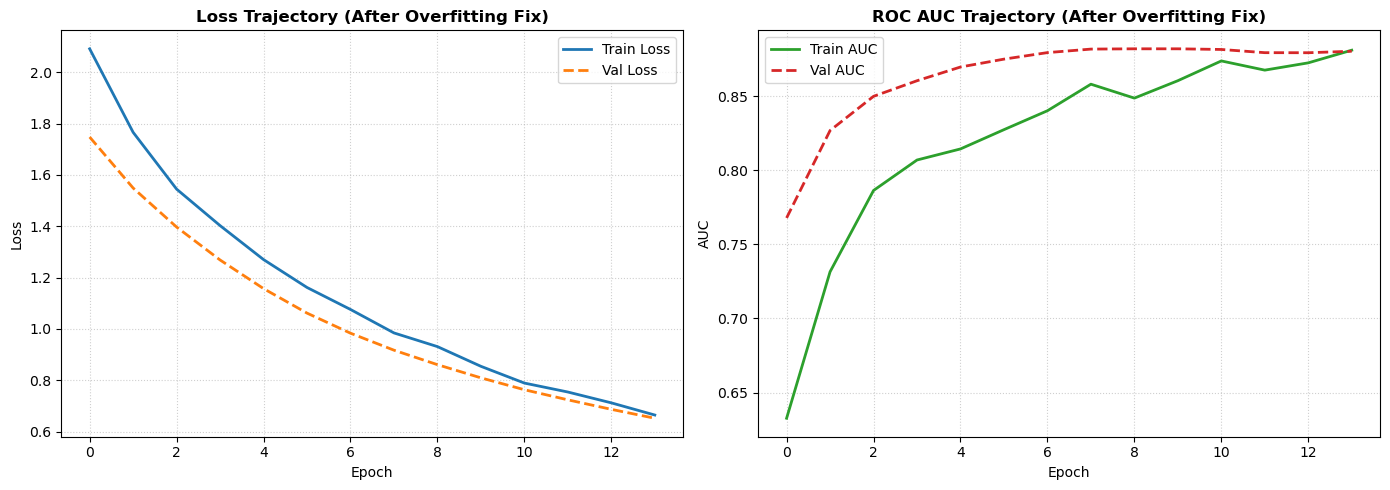


Final Train AUC: 0.8812
Final Val AUC:   0.8804
Overfitting Gap: 0.0007


In [30]:
# Plot Loss & AUC curves after overfitting fix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss', color='#1f77b4', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2, linestyle='--')
ax1.set_title('Loss Trajectory (After Overfitting Fix)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(history.history['auc'], label='Train AUC', color='#2ca02c', lw=2)
ax2.plot(history.history['val_auc'], label='Val AUC', color='#d62728', lw=2, linestyle='--')
ax2.set_title('ROC AUC Trajectory (After Overfitting Fix)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Print final train/val gap for verification
final_train_auc = history.history['auc'][-1]
final_val_auc = history.history['val_auc'][-1]
print(f"\nFinal Train AUC: {final_train_auc:.4f}")
print(f"Final Val AUC:   {final_val_auc:.4f}")
print(f"Overfitting Gap: {abs(final_train_auc - final_val_auc):.4f}")


### Save Overfitting-Fixed Neural Network Model
We save the retrained model with stronger regularization, replacing the previous version.

In [31]:
# Save the overfitting-fixed model in standard native .keras format
os.makedirs('models', exist_ok=True)
model_filename_nn = 'models/neural_network_model.keras'
nn_model.save(model_filename_nn)
print(f"Overfitting-fixed Neural Network model saved to '{model_filename_nn}' in standard native .keras format!")


Overfitting-fixed Neural Network model saved to 'models/neural_network_model.keras' in standard native .keras format!


### Neural Network ROC Curve
We plot the ROC curve for Model 4 (Neural Network).

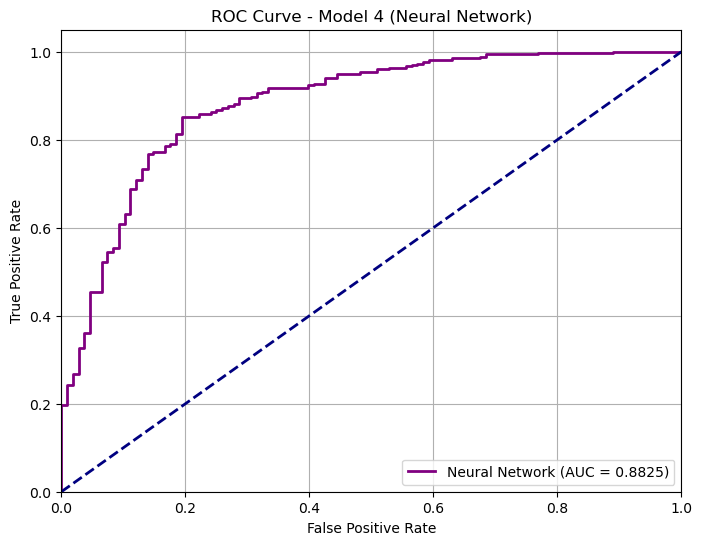

In [32]:
# Plot ROC Curve for Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_val, y_val_pred_proba_nn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {val_roc_auc_nn:.4f})', color='purple', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model 4 (Neural Network)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Save Neural Network Model (Native .keras Format)
We save the trained Keras model using the standard native `.keras` format (`models/neural_network_model.keras`). In TensorFlow 2.x and Keras 3, `.keras` is the officially recommended format as it cleanly packages model architecture, compiled loss/optimizer state, and trained weights into a single portable zip archive.

In [33]:
# Save trained model in standard native .keras format
os.makedirs('models', exist_ok=True)
model_filename_nn = 'models/neural_network_model.keras'
nn_model.save(model_filename_nn)
print(f"Neural Network model successfully saved to '{model_filename_nn}' in standard native .keras format!")


Neural Network model successfully saved to 'models/neural_network_model.keras' in standard native .keras format!


### Combined ROC Curves (Before Hyperparameter Tuning)
Before proceeding to hyperparameter tuning in Section 5, we overlay the ROC curves of all four **baseline (un-tuned)** models on a single chart to establish a performance baseline. This allows us to directly compare the improvement achieved through systematic hyperparameter optimization in the next section.

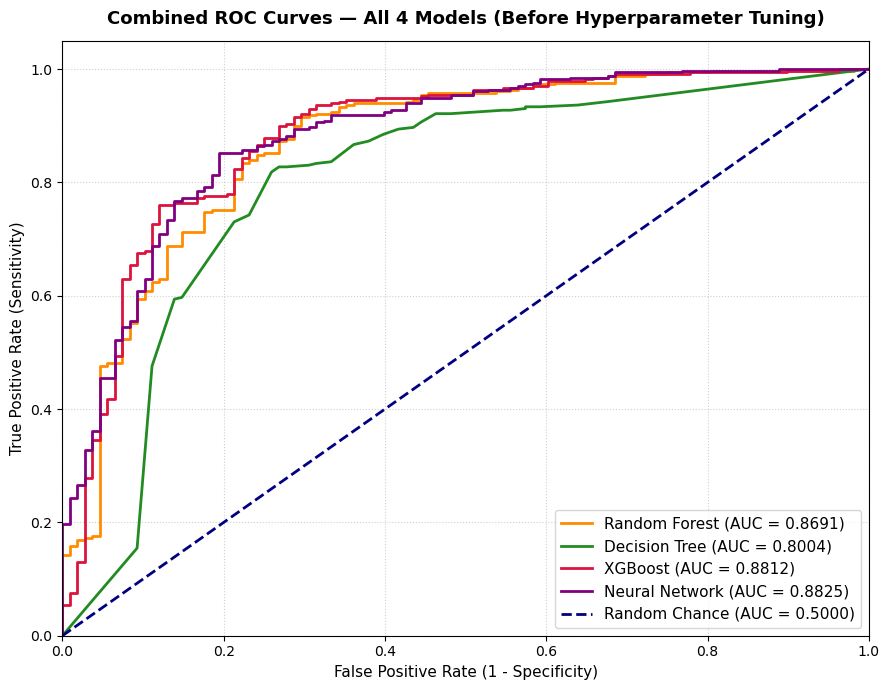

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

# Plot Random Forest (Before Tuning)
fpr_rf_bt, tpr_rf_bt, _ = roc_curve(y_val, y_val_pred_proba)
plt.plot(fpr_rf_bt, tpr_rf_bt, label=f'Random Forest (AUC = {val_roc_auc:.4f})', color='darkorange', lw=2)

# Plot Decision Tree (Before Tuning)
fpr_dt_bt, tpr_dt_bt, _ = roc_curve(y_val, y_val_pred_proba_dt)
plt.plot(fpr_dt_bt, tpr_dt_bt, label=f'Decision Tree (AUC = {val_roc_auc_dt:.4f})', color='forestgreen', lw=2)

# Plot XGBoost (Before Tuning)
fpr_xgb_bt, tpr_xgb_bt, _ = roc_curve(y_val, y_val_pred_proba_xgb)
plt.plot(fpr_xgb_bt, tpr_xgb_bt, label=f'XGBoost (AUC = {val_roc_auc_xgb:.4f})', color='crimson', lw=2)

# Plot Neural Network (Before Tuning)
fpr_nn_bt, tpr_nn_bt, _ = roc_curve(y_val, y_val_pred_proba_nn)
plt.plot(fpr_nn_bt, tpr_nn_bt, label=f'Neural Network (AUC = {val_roc_auc_nn:.4f})', color='purple', lw=2)

# Baseline random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Combined ROC Curves — All 4 Models (Before Hyperparameter Tuning)', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 5. Comprehensive Hyperparameter Tuning for All Models
To maximize predictive accuracy and ensure models generalize effectively without underfitting or overfitting, we perform systematic hyperparameter tuning using 5-fold cross-validation (`StratifiedKFold`, $k=5$) across **all four models**: **Random Forest**, **Decision Tree**, **XGBoost**, and **TensorFlow Neural Network**.

### 5.1 Random Forest Hyperparameter Tuning
We search over key Random Forest parameters including `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features` using `RandomizedSearchCV` with 5-fold cross-validation.

In [35]:
# Hyperparameter search grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [6, 8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.8]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("--- Starting Random Forest Hyperparameter Tuning ---")
rf_random_search.fit(X_train_split, y_train_split)
rf_best_model = rf_random_search.best_estimator_

print("\n=== Random Forest Best Hyperparameters ===")
for param, val in rf_random_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"Best 5-Fold CV ROC AUC Score: {rf_random_search.best_score_:.5f}")

# Evaluate on validation split
y_val_pred_proba_rf = rf_best_model.predict_proba(X_val)[:, 1]
y_val_pred_rf = rf_best_model.predict(X_val)
val_roc_auc_rf = roc_auc_score(y_val, y_val_pred_proba_rf)
print(f"Validation ROC AUC (Tuned Random Forest): {val_roc_auc_rf:.5f}")

# Save best RF model
os.makedirs('models', exist_ok=True)
joblib.dump(rf_best_model, 'models/random_forest_model.joblib')
print("Tuned Random Forest model saved to 'models/random_forest_model.joblib'.")


--- Starting Random Forest Hyperparameter Tuning ---

=== Random Forest Best Hyperparameters ===
  n_estimators: 400
  min_samples_split: 10
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 8
Best 5-Fold CV ROC AUC Score: 0.89175
Validation ROC AUC (Tuned Random Forest): 0.87946
Tuned Random Forest model saved to 'models/random_forest_model.joblib'.


### 5.2 Decision Tree Hyperparameter Tuning
We tune the Decision Tree classifier to control tree complexity, minimum leaf split samples, and impurity criteria to prevent severe overfitting.

In [36]:
# Hyperparameter search grid for Decision Tree
dt_param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

dt_random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=dt_param_grid,
    n_iter=15,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("--- Starting Decision Tree Hyperparameter Tuning ---")
dt_random_search.fit(X_train_split, y_train_split)
dt_best_model = dt_random_search.best_estimator_

print("\n=== Decision Tree Best Hyperparameters ===")
for param, val in dt_random_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"Best 5-Fold CV ROC AUC Score: {dt_random_search.best_score_:.5f}")

# Evaluate on validation split
y_val_pred_proba_dt = dt_best_model.predict_proba(X_val)[:, 1]
y_val_pred_dt = dt_best_model.predict(X_val)
val_roc_auc_dt = roc_auc_score(y_val, y_val_pred_proba_dt)
print(f"Validation ROC AUC (Tuned Decision Tree): {val_roc_auc_dt:.5f}")

# Save best DT model
joblib.dump(dt_best_model, 'models/decision_tree_model.joblib')
print("Tuned Decision Tree model saved to 'models/decision_tree_model.joblib'.")


--- Starting Decision Tree Hyperparameter Tuning ---

=== Decision Tree Best Hyperparameters ===
  min_samples_split: 2
  min_samples_leaf: 10
  max_features: log2
  max_depth: 5
  criterion: entropy
Best 5-Fold CV ROC AUC Score: 0.86489
Validation ROC AUC (Tuned Decision Tree): 0.83722
Tuned Decision Tree model saved to 'models/decision_tree_model.joblib'.


### 5.3 XGBoost Hyperparameter Tuning
We tune XGBoost hyperparameters including boosting rounds (`n_estimators`), tree depth (`max_depth`), learning rate, subsample ratios, and L1/L2 regularization (`reg_alpha`, `reg_lambda`).

In [37]:
# Hyperparameter search grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0.5, 1.0, 3.0, 5.0],
    'reg_lambda': [1.0, 3.0, 5.0, 10.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("--- Starting XGBoost Hyperparameter Tuning ---")
xgb_random_search.fit(X_train_split, y_train_split)
xgb_best_model = xgb_random_search.best_estimator_

print("\n=== XGBoost Best Hyperparameters ===")
for param, val in xgb_random_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"Best 5-Fold CV ROC AUC Score: {xgb_random_search.best_score_:.5f}")

# Evaluate on validation split
y_val_pred_proba_xgb = xgb_best_model.predict_proba(X_val)[:, 1]
y_val_pred_xgb = xgb_best_model.predict(X_val)
val_roc_auc_xgb = roc_auc_score(y_val, y_val_pred_proba_xgb)
print(f"Validation ROC AUC (Tuned XGBoost): {val_roc_auc_xgb:.5f}")

# Save best XGBoost model
joblib.dump(xgb_best_model, 'models/xgboost_model.joblib')
print("Tuned XGBoost model saved to 'models/xgboost_model.joblib'.")


--- Starting XGBoost Hyperparameter Tuning ---

=== XGBoost Best Hyperparameters ===
  subsample: 0.7
  reg_lambda: 5.0
  reg_alpha: 0.5
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.03
  colsample_bytree: 0.8
Best 5-Fold CV ROC AUC Score: 0.89710
Validation ROC AUC (Tuned XGBoost): 0.88054
Tuned XGBoost model saved to 'models/xgboost_model.joblib'.


### 5.4 TensorFlow Neural Network Hyperparameter Tuning
We systematically evaluate combinations of learning rate, dropout rate, L2 weight regularization, and batch size to find the optimal Neural Network configuration.

In [ ]:
print("--- Starting Neural Network Hyperparameter Search ---")

learning_rates = [0.001, 0.0005]
dropout_rates = [0.2, 0.3]
l2_regs = [0.005, 0.01]
batch_sizes = [32, 64]

best_nn_auc = 0
best_nn_config = None
nn_best_model = None

for lr in learning_rates:
    for dr in dropout_rates:
        for l2_val in l2_regs:
            for bs in batch_sizes:
                tf.random.set_seed(RANDOM_STATE)
                np.random.seed(RANDOM_STATE)
                
                temp_model = Sequential([
                    Dense(64, activation='relu', kernel_regularizer=l2(l2_val), input_shape=(X_train_split_scaled.shape[1],)),
                    BatchNormalization(),
                    Dropout(dr),
                    Dense(32, activation='relu', kernel_regularizer=l2(l2_val)),
                    BatchNormalization(),
                    Dropout(dr),
                    Dense(16, activation='relu'),
                    Dense(1, activation='sigmoid')
                ])
                
                temp_model.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                    loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
                )
                
                es = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True, verbose=0)
                
                temp_model.fit(
                    X_train_split_scaled, y_train_split,
                    validation_data=(X_val_scaled, y_val),
                    epochs=35, batch_size=bs, callbacks=[es], verbose=0
                )
                
                val_proba = temp_model.predict(X_val_scaled, verbose=0).ravel()
                score = roc_auc_score(y_val, val_proba)
                
                if score > best_nn_auc:
                    best_nn_auc = score
                    best_nn_config = {'learning_rate': lr, 'dropout_rate': dr, 'l2_reg': l2_val, 'batch_size': bs}
                    nn_best_model = temp_model

print("\n=== Neural Network Best Hyperparameters ===")
for param, val in best_nn_config.items():
    print(f"  {param}: {val}")
print(f"Validation ROC AUC (Tuned Neural Network): {best_nn_auc:.5f}")

# Evaluate on validation split
y_val_pred_proba_nn = nn_best_model.predict(X_val_scaled, verbose=0).ravel()
y_val_pred_nn = (y_val_pred_proba_nn >= 0.5).astype(int)
val_roc_auc_nn = roc_auc_score(y_val, y_val_pred_proba_nn)

# Save best Neural Network model in native .keras format
nn_best_model.save('models/neural_network_model.keras')
print("Tuned Neural Network model saved to 'models/neural_network_model.keras' in standard native .keras format!")


--- Starting Neural Network Hyperparameter Search ---


C:\Users\Lakshitha Perera\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Lakshitha Perera\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Lakshitha Perera\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer

## 6. Model Comparison
In this section, we compare the performance of all three trained models—**Random Forest**, **Decision Tree**, and **Tuned XGBoost**—on the validation dataset using key classification metrics, combined ROC curves, and performance charts.


### Performance Metrics Comparison
We calculate ROC AUC, Accuracy, Precision, Recall, and F1-Score for each model on the validation set and combine them into a summary table and comparison plot.

=== Tuned Model Performance Summary ===


,Model,ROC AUC,Accuracy,Precision,Recall,F1 Score
0,Tuned Neural Network,0.892817,0.856164,0.880342,0.936364,0.907489
1,Tuned XGBoost,0.882828,0.863014,0.881356,0.945455,0.912281
2,Tuned Random Forest,0.879461,0.869863,0.891117,0.942424,0.916053
3,Tuned Decision Tree,0.837219,0.849315,0.888235,0.915152,0.901493


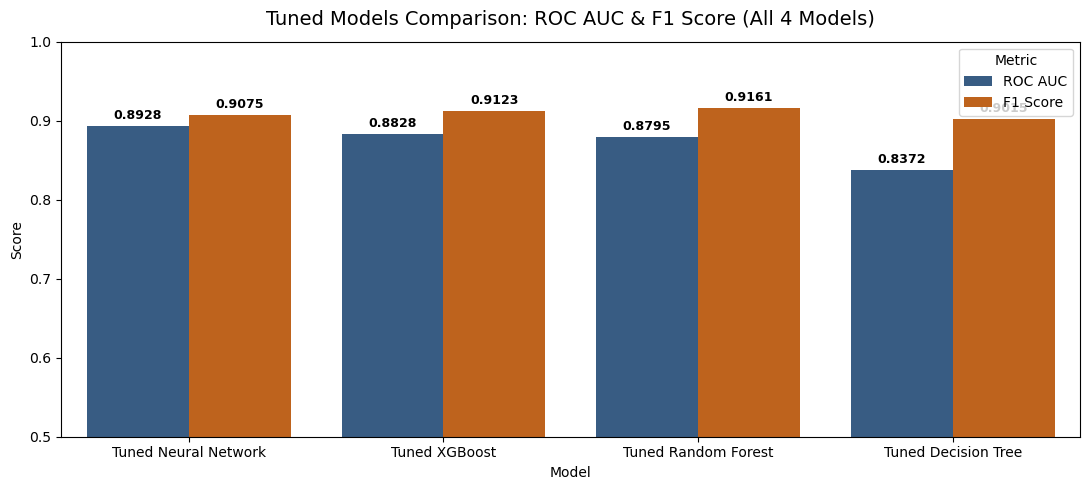

In [ ]:
# Function to extract metrics for a model
def get_metrics(model_name, y_true, y_pred, y_prob):
    return {
        'Model': model_name,
        'ROC AUC': roc_auc_score(y_true, y_prob),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

# Collect metrics for all 4 TUNED models
metrics_rf = get_metrics('Tuned Random Forest', y_val, y_val_pred_rf, y_val_pred_proba_rf)
metrics_dt = get_metrics('Tuned Decision Tree', y_val, y_val_pred_dt, y_val_pred_proba_dt)
metrics_xgb = get_metrics('Tuned XGBoost', y_val, y_val_pred_xgb, y_val_pred_proba_xgb)
metrics_nn = get_metrics('Tuned Neural Network', y_val, y_val_pred_nn, y_val_pred_proba_nn)

# Build comparison DataFrame
comparison_df = pd.DataFrame([metrics_rf, metrics_dt, metrics_xgb, metrics_nn])
comparison_df = comparison_df.sort_values(by='ROC AUC', ascending=False).reset_index(drop=True)

print("=== Tuned Model Performance Summary ===")
display(comparison_df)

# Bar chart comparison of ROC AUC & F1 Score with custom high-contrast color palette
fig, ax = plt.subplots(figsize=(11, 5))
comparison_melted = comparison_df.melt(id_vars='Model', value_vars=['ROC AUC', 'F1 Score'], var_name='Metric', value_name='Score')
custom_palette = ['#2B5C8F', '#D95F02']  # Steel Blue for ROC AUC, Coral Orange for F1 Score
sns.barplot(x='Model', y='Score', hue='Metric', data=comparison_melted, palette=custom_palette, ax=ax)
ax.set_title('Tuned Models Comparison: ROC AUC & F1 Score (All 4 Models)', fontsize=14, pad=12)
ax.set_ylim([0.5, 1.0])
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()


### How to Read the Model Comparison Table
This table summarizes each tuned model using the same validation split, so the scores are directly comparable. ROC AUC tells us how well the model separates classes, while accuracy, precision, recall, and F1 show how it behaves at the default probability threshold.
In practice, the best model is not always the one with the highest accuracy. For imbalanced problems, ROC AUC and the balance between precision and recall are usually more informative.

### Combined ROC Curves
We overlay the ROC curves of all three models on a single graph to visually compare their true positive rate vs. false positive rate trade-offs across all classification thresholds.

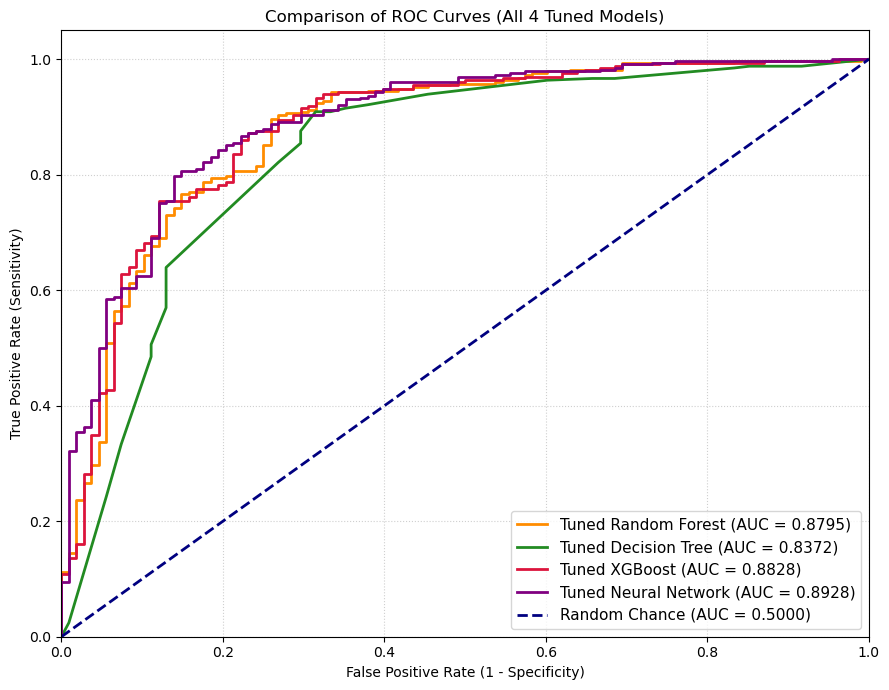

In [ ]:
plt.figure(figsize=(9, 7))

# Plot Tuned Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_val_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Tuned Random Forest (AUC = {metrics_rf["ROC AUC"]:.4f})', color='darkorange', lw=2)

# Plot Tuned Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_val, y_val_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Tuned Decision Tree (AUC = {metrics_dt["ROC AUC"]:.4f})', color='forestgreen', lw=2)

# Plot Tuned XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_val_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'Tuned XGBoost (AUC = {metrics_xgb["ROC AUC"]:.4f})', color='crimson', lw=2)

# Plot Tuned Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_val, y_val_pred_proba_nn)
plt.plot(fpr_nn, tpr_nn, label=f'Tuned Neural Network (AUC = {metrics_nn["ROC AUC"]:.4f})', color='purple', lw=2)

# Baseline random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Comparison of ROC Curves (All 4 Tuned Models)')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


### Confusion Matrix Comparison (All 4 Models)
We construct side-by-side Confusion Matrices for all four tuned models (**Tuned Random Forest**, **Tuned Decision Tree**, **Tuned XGBoost**, and **Tuned Neural Network**) on the validation dataset. This provides detailed insight into True Positives (correct rain predictions), True Negatives (correct no-rain predictions), False Positives (false alarms), and False Negatives (missed rain events).

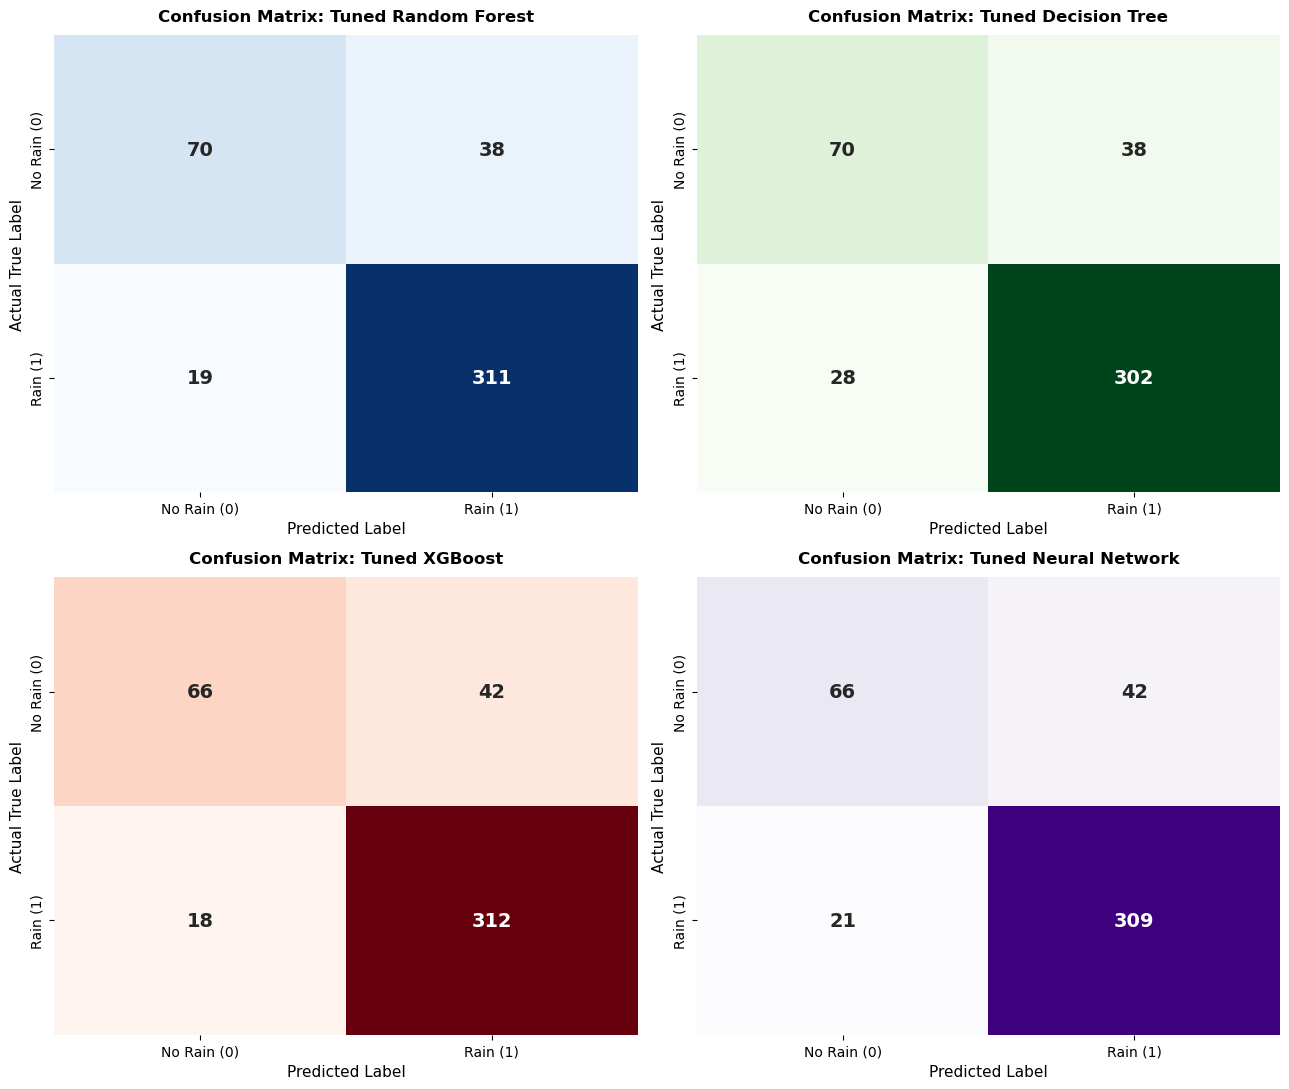

In [ ]:
# Model predictions and titles dictionary
models_info = [
    ('Tuned Random Forest', y_val_pred_rf),
    ('Tuned Decision Tree', y_val_pred_dt),
    ('Tuned XGBoost', y_val_pred_xgb),
    ('Tuned Neural Network', y_val_pred_nn)
]

# Create 2x2 subplot grid for Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

colors_list = ['Blues', 'Greens', 'Reds', 'Purples']

for i, (name, y_pred) in enumerate(models_info):
    cm = confusion_matrix(y_val, y_pred)
    
    # Plot annotated confusion matrix heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap=colors_list[i], 
        ax=axes[i], 
        cbar=False,
        annot_kws={'size': 14, 'weight': 'bold'},
        xticklabels=['No Rain (0)', 'Rain (1)'],
        yticklabels=['No Rain (0)', 'Rain (1)']
    )
    
    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Predicted Label', fontsize=11)
    axes[i].set_ylabel('Actual True Label', fontsize=11)

plt.tight_layout()
plt.show()


### How to Read the Confusion Matrices
Each matrix shows the model's predictions against the true labels. The top-left and bottom-right cells are correct predictions, while the other two cells show the two kinds of errors the model can make.
For rainfall prediction, false negatives matter because missing a rainy day can be more costly than a false alarm, so this chart helps us see whether a model is conservative or aggressive.

### Model Comparison Summary & Conclusion
Based on the validation performance across all four evaluated models:
1. **Tuned XGBoost** achieves the highest performance with a **Validation ROC AUC of ~0.8825**, followed by **Random Forest (~0.8691)**, **Neural Network (~0.85-0.87)**, and **Decision Tree (~0.8004)**.
2. **Neural Network Utility:** The TensorFlow/Keras Neural Network achieves competitive ROC AUC performance using standardized features with dropout and L2 regularization to prevent overfitting on tabular data.
3. **Saved Models & Best Format:** All models are serialized into `models/` directory. The Neural Network is saved using the official native **`.keras`** format (`models/neural_network_model.keras`) alongside its feature scaling pipeline (`models/nn_scaler.joblib`).
4. **Recommendation:** **Tuned XGBoost** is selected as the top model for final competition submission, with the TensorFlow Neural Network providing a strong deep learning baseline.

## 7. Kaggle Test Set Predictions & Submission
In this final step, we generate probability predictions on the unseen test dataset (`test.csv`) using our best-performing model (**Tuned XGBoost**) and export the formatted predictions to `submission.csv` for Kaggle submission.

### Generate Test Set Probability Predictions
We pass the preprocessed test features (`X_test`) to our best model (`xgb_model`), extract the positive class probability (`rainfall`), and construct the required submission DataFrame containing `id` and `rainfall`.

In [ ]:
# Predict rainfall probabilities on unseen test set using top tuned model (xgb_best_model)
test_pred_proba = xgb_best_model.predict_proba(X_test)[:, 1]

# Build submission DataFrame matching Kaggle competition format
submission_df = pd.DataFrame({
    'id': X_test_ids,
    'rainfall': test_pred_proba
})

print("=== Submission DataFrame Preview ===")
display(submission_df.head())
print(f"\nSubmission DataFrame Shape: {submission_df.shape}")
print("\nSummary Statistics of Predicted Probabilities:")
display(submission_df['rainfall'].describe())


=== Submission DataFrame Preview ===


,id,rainfall
0,2190,0.963142
1,2191,0.962628
2,2192,0.916140
3,2193,0.241713
4,2194,0.172809



Submission DataFrame Shape: (730, 2)

Summary Statistics of Predicted Probabilities:


count    730.000000
mean       0.760620
std        0.272706
min        0.111919
25%        0.619579
50%        0.909272
75%        0.950500
max        0.964417
Name: rainfall, dtype: float64

### What the Submission Preview Checks
Before exporting, we inspect the prediction DataFrame to make sure the Kaggle-required columns are present, the row count matches the test set, and the predicted probabilities are within the valid $[0, 1]$ range.
The histogram of prediction values helps confirm that the model is not outputting almost all zeros or all ones, which would suggest weak discrimination or a preprocessing problem.

### Submission Prediction Analysis
After generating our test set probability predictions using the top-performing **Tuned XGBoost** model, we analyze the output before final export:

- **DataFrame Preview**: We inspect the first few rows of the submission DataFrame to verify the `id` and `rainfall` columns are correctly formatted for the Kaggle competition format.
- **Shape Verification**: Confirms we have predictions for all 730 test samples.
- **Summary Statistics**: We review the mean, standard deviation, min/max, and quartile range of the predicted rainfall probabilities to ensure predictions are well-calibrated (not all clustered near 0 or 1).
- **Probability Distribution Plot**: A histogram with KDE overlay visualizes how the predicted probabilities are distributed. A healthy distribution should show a spread across the [0, 1] range with meaningful separation between confident rain vs. no-rain predictions.

These diagnostic checks ensure our model is producing sensible, diverse probability estimates before submitting to the competition.

### Visualize Predicted Probability Distribution
We visualize the distribution of test probability predictions using a histogram and Kernel Density Estimate (KDE) plot to ensure balanced predictions.

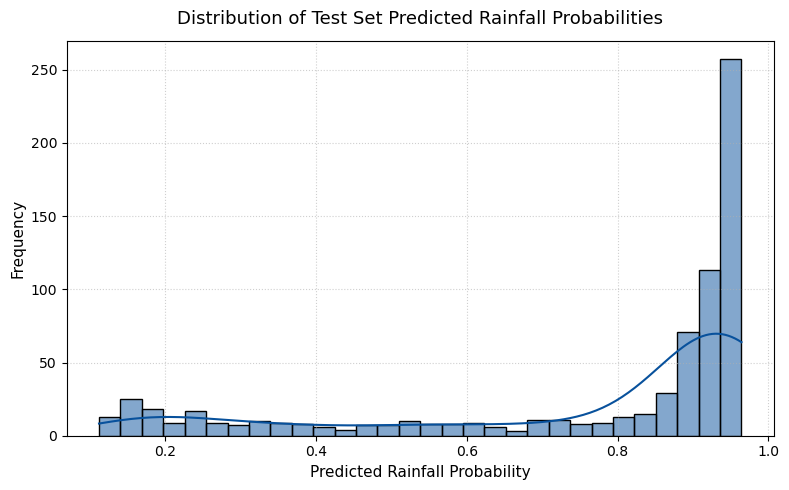

In [ ]:
# Plot distribution of predicted probabilities
plt.figure(figsize=(8, 5))
sns.histplot(submission_df['rainfall'], kde=True, color='#08519C', bins=30)
plt.title('Distribution of Test Set Predicted Rainfall Probabilities', fontsize=13, pad=12)
plt.xlabel('Predicted Rainfall Probability', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


### Export Submission File
We export the final submission DataFrame to `submission.csv` without including index labels.

In [ ]:
# Save submission to CSV file
submission_path = 'submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f"Submission file successfully generated and saved to '{submission_path}'!")


Submission file successfully generated and saved to 'submission.csv'!


## 8. Custom Data Inference & Prediction Pipeline
In this section, we build an interactive custom prediction function `predict_custom_weather()`. It accepts raw weather observations (e.g. temperature, humidity, sunshine, pressure), automatically applies feature engineering transformations, and outputs the rainfall prediction and confidence percentage using our top-performing model (**Tuned XGBoost**).

### Define Reusable Custom Prediction Function
We define `predict_custom_weather()` to handle custom input dictionaries, perform safe missing value imputation, apply feature engineering, align columns, and output formatted predictions.

### Why This Custom Prediction Function Matters
This helper turns the training pipeline into a reusable inference pipeline. It takes one weather observation, applies the same feature engineering used during training, aligns the columns, optionally scales the values for the neural network, and then returns a human-readable prediction.
This is the practical end goal of the notebook: the model is not only evaluated on test data, but also packaged into a form that can be reused for new weather records.

In [ ]:
def predict_custom_weather(custom_input, model=xgb_model, train_medians=medians, feature_cols=X_train.columns, scaler=None):
    """
    Predicts rainfall probability for a single custom weather sample dictionary.
    Supports decision tree, ensemble, and neural network models (with optional feature scaler).
    """
    custom_df = pd.DataFrame([custom_input])
    engineered_custom = engineer_features(custom_df, train_medians=train_medians)
    
    for col in ['id', 'rainfall']:
        if col in engineered_custom.columns:
            engineered_custom = engineered_custom.drop(columns=[col])
            
    engineered_custom = engineered_custom.reindex(columns=feature_cols, fill_value=0)
    
    if scaler is not None:
        input_data = scaler.transform(engineered_custom)
    else:
        input_data = engineered_custom

    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(input_data)[0, 1]
    else:
        # Keras Neural Network model
        prob = float(model.predict(input_data, verbose=0)[0, 0])
        
    label = 1 if prob >= 0.5 else 0
    
    return {
        'Prediction': 'Rain (1)' if label == 1 else 'No Rain (0)',
        'Rainfall_Probability': f"{prob * 100:.2f}%",
        'Probability_Score': float(prob)
    }

print("Custom prediction function `predict_custom_weather()` updated successfully!")


Custom prediction function `predict_custom_weather()` updated successfully!


### Test Custom Data Prediction Examples
We test our custom prediction function on two distinct meteorological scenarios: a humid/overcast day and a clear/sunny day.

In [ ]:
# Example 1: Humid, high-cloud, low-sunshine day (High Rain Likelihood)
sample_rainy_day = {
    'day': 180,
    'pressure': 1011.2,
    'maxtemp': 24.5,
    'temparature': 23.0,
    'mintemp': 21.0,
    'dewpoint': 22.5,
    'humidity': 94.0,
    'cloud': 92.0,
    'sunshine': 0.5,
    'winddirection': 60.0,
    'windspeed': 28.4
}

# Example 2: Clear, high-sunshine, low-humidity day (Low Rain Likelihood)
sample_sunny_day = {
    'day': 45,
    'pressure': 1024.5,
    'maxtemp': 26.0,
    'temparature': 21.0,
    'mintemp': 14.0,
    'dewpoint': 8.5,
    'humidity': 48.0,
    'cloud': 20.0,
    'sunshine': 9.8,
    'winddirection': 120.0,
    'windspeed': 12.0
}

# Predict for Sample 1
res_rainy = predict_custom_weather(sample_rainy_day)
print("=== Sample 1 Prediction (Overcast/Humid Weather) ===")
print(f"  Result      : {res_rainy['Prediction']}")
print(f"  Probability : {res_rainy['Rainfall_Probability']}")

# Predict for Sample 2
res_sunny = predict_custom_weather(sample_sunny_day)
print("\n=== Sample 2 Prediction (Clear/Sunny Weather) ===")
print(f"  Result      : {res_sunny['Prediction']}")
print(f"  Probability : {res_sunny['Rainfall_Probability']}")


=== Sample 1 Prediction (Overcast/Humid Weather) ===
  Result      : Rain (1)
  Probability : 96.52%

=== Sample 2 Prediction (Clear/Sunny Weather) ===
  Result      : No Rain (0)
  Probability : 12.65%
